## XYZ Network User Life Time Value Model and Analysis 
* Brand: All 5 Linear Brands
* Feature window: 2023-01-01 to 2023-06-30
* LTV label window: 2023-07-01 to 2023-12-31
* Datasets: Viewership, Online Content, Subscription

In [70]:
import pandas as pd
import re
import numpy as np
import xgboost as xgb
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, roc_auc_score, recall_score, precision_score, f1_score, accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.cluster import KMeans
from sklearn.metrics import classification_report
from sklearn.model_selection import GridSearchCV
import shap
import plotly.graph_objects as go
from IPython.display import display

import warnings
warnings.filterwarnings('ignore')

In [71]:
select_brand = ['LimeLight', 'Pulse', 'ChillStream', 'RetroReel', 'CineQuest']
train_start, train_end = '2023-01-01','2023-06-30'
color_palette = {'High-Value': 'seagreen', 'Mid-Value': 'bisque', 'Low-Value': 'lightcoral'}

seed = 21

### Viewership Processing and Clustering

In [72]:
view1 = pd.read_csv('Data/XYZ_NETWORKS_VIEWERSHIP_DATA_1.csv')
view2 = pd.read_csv('Data/XYZ_NETWORKS_VIEWERSHIP_DATA_2.csv')
view3 = pd.read_csv('Data/XYZ_NETWORKS_VIEWERSHIP_DATA_3.csv')

combined_view = pd.concat([view1, view2, view3], axis=0, ignore_index=True)

In [73]:
## remove nas and impute nas
view_cleaned = combined_view.dropna(subset=['ID', 'NETWORK', 'PROGRAM_NAME', 'EVENT_START_TIMESTAMP', 'DURATION_SECONDS'])
view_cleaned['GENRE'] = view_cleaned['GENRE'].fillna('Other')
view_cleaned.drop('ROW_NUM', axis=1, inplace=True)
view_cleaned.drop_duplicates(inplace=True)

## filter DURATION_SECONDS >= 360
view_filtered = view_cleaned[view_cleaned['DURATION_SECONDS'] >= 360]

linear_networks = ['LimeLight', 'Pulse', 'ChillStream', 'RetroReel', 'CineQuest']
fast_networks = ['Adrenaline', 'DarkMatter', 'SilverScreen Classics', 
                 'TimeCapsule TV', 'TasteMakers', 'DesignLab', 'PopCulture Now']

def get_network_type(network):
    """
    Return 'PAID' if the network is in the paid_networks list, else 'UNPAID'.
    
    Parameters:
    network (str): The network name to check.
    paid_networks (list): List of paid networks.

    Returns:
    str: 'PAID' if the network is in paid_networks, else 'UNPAID'.
    """
    if network in linear_networks:
        return 'LINEAR'
    elif network in fast_networks:
        return 'FAST'
    else:
        return 'REAL'

view_filtered['NETWORK_TYPE'] = view_filtered['NETWORK'].apply(get_network_type)
view_filtered = view_filtered[view_filtered['NETWORK_TYPE'] != 'REAL']

view_filtered['DURATION_MINUTES'] = view_filtered['DURATION_SECONDS'] / 60
view_filtered['DURATION_MINUTES'] = view_filtered['DURATION_MINUTES'].round(1)
view_filtered['AD_REVENUE'] = (0.25/3600) * view_filtered['DURATION_SECONDS']
view_filtered.drop(columns='DURATION_SECONDS', inplace=True)

# Convert 'EVENT_START_TIMESTAMP' to datetime
view_filtered['EVENT_START_TIMESTAMP'] = pd.to_datetime(view_filtered['EVENT_START_TIMESTAMP'], utc = False)
def localize(x):
    return x.tz_localize(None)
view_filtered['EVENT_START_TIMESTAMP'] = view_filtered['EVENT_START_TIMESTAMP'].apply(localize)

In [74]:
def groupby_df(df, current_day):
    current_day = pd.to_datetime(current_day)
    
    # Group by 'ID' and 'NETWORK' to find the first and last watch dates
    df_watch_dates = df.groupby(['ID', 'NETWORK'])['EVENT_START_TIMESTAMP'].agg(
        FIRST_WATCH_DATE='min',
        LAST_WATCH_DATE='max'
    ).reset_index()
    
    # Calculate 'TENURE' as the difference between last and first watch dates
    df_watch_dates['TENURE'] = (df_watch_dates['LAST_WATCH_DATE'] - df_watch_dates['FIRST_WATCH_DATE']).dt.days + 1
    # Calculate 'RECENCY' as the difference between current day and last watch date
    df_watch_dates['RECENCY'] = (current_day - df_watch_dates['LAST_WATCH_DATE']).dt.days
    
    # Group by 'ID' and 'NETWORK' to find the number of sessions as 'FREQUENCY'
    df_num_sessions = df.groupby(['ID', 'NETWORK']).size().reset_index(name='FREQUENCY')
    
    # Group by 'ID' and 'NETWORK' to find the sum of duration
    df_sum_duration = df.groupby(['ID', 'NETWORK'])['DURATION_MINUTES'].sum().reset_index()
    df_sum_duration = df_sum_duration.rename(columns={'DURATION_MINUTES': 'SUM_DURATION'})
    
    # Merge all data into a final DataFrame
    df_final = pd.merge(df_watch_dates, df_num_sessions, on=['ID', 'NETWORK'])
    df_final = pd.merge(df_final, df_sum_duration, on=['ID', 'NETWORK'])
    
    df_final = df_final[['ID', 'NETWORK', 'RECENCY', 'FREQUENCY', 'TENURE', 'SUM_DURATION']]
    
    return df_final

In [75]:
view_filtered = view_filtered[(view_filtered['EVENT_START_TIMESTAMP'] >= train_start) & (view_filtered['EVENT_START_TIMESTAMP'] <= train_end)]
view_final = groupby_df(view_filtered, train_end)
view_final = view_final[view_final['NETWORK'].isin(select_brand)]

In [76]:
## Helper Function

def plot_sse_elbow(data, columns, k_range=range(1, 10), max_iter=1000):
    """
    Plots SSE for a range of cluster numbers to help determine the optimal number of clusters.
    
    Parameters:
    - data: pandas DataFrame containing your data.
    - columns: list of column names to use for clustering.
    - k_range: range of cluster numbers to try (default is range(1, 10)).
    - max_iter: maximum number of iterations for the KMeans algorithm (default is 1000).
    """
    sse = {}
    X = data[[columns]]
    for k in k_range:
        kmeans = KMeans(n_clusters=k, max_iter=max_iter, random_state=seed)
        kmeans.fit(X)
        sse[k] = kmeans.inertia_
    plt.figure()
    plt.plot(list(sse.keys()), list(sse.values()))
    plt.xlabel("Number of clusters")
    plt.ylabel("SSE")
    plt.title("Elbow Method for Optimal k")
    plt.show()

def perform_kmeans(data, columns, n_clusters, new_column_name):
    """
    Performs KMeans clustering and adds cluster labels to the dataframe.
    
    Parameters:
    - data: pandas DataFrame containing your data.
    - columns: list of column names to use for clustering.
    - n_clusters: number of clusters to form.
    - new_column_name: name of the new column to store cluster labels.
    
    Returns:
    - data: DataFrame with new cluster labels column.
    """
    kmeans = KMeans(n_clusters=n_clusters, random_state=seed)
    kmeans.fit(data[[columns]])
    data[new_column_name] = kmeans.predict(data[[columns]])
    return data

def order_cluster(cluster_field_name, target_field_name, df, ascending):
    """
    Sorting clusters 
    """
    new_cluster_field_name = 'new_' + cluster_field_name
    df_new = df.groupby(cluster_field_name)[target_field_name].mean().reset_index()
    df_new = df_new.sort_values(by=target_field_name, ascending=ascending).reset_index(drop=True)
    df_new['index'] = df_new.index
    
    df_final = pd.merge(df, df_new[[cluster_field_name,'index']], on=cluster_field_name)
    df_final = df_final.drop([cluster_field_name],axis=1)
    df_final = df_final.rename(columns={"index":cluster_field_name})
    return df_final

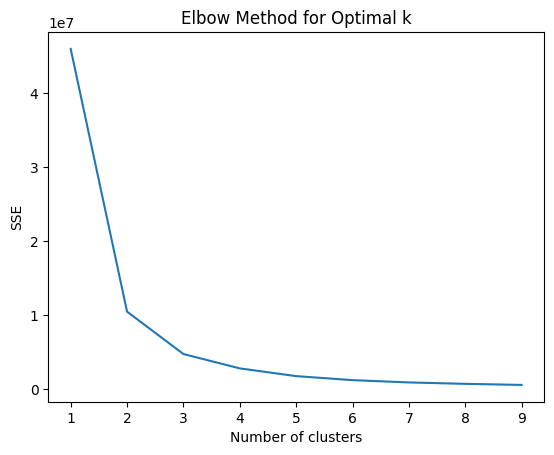

In [77]:
plot_sse_elbow(view_final, 'RECENCY')

In [78]:
view_final = perform_kmeans(view_final, 'RECENCY', 3, 'RecencyCluster')
view_final = order_cluster('RecencyCluster', 'RECENCY', view_final, False)
view_final.groupby('RecencyCluster')['RECENCY'].describe()

,count,mean,std,min,25%,50%,75%,max
RecencyCluster,,,,,,,,
0,4656.0,147.664948,17.873943,118.0,132.0,147.0,164.0,179.0
1,4792.0,86.834725,17.778532,57.0,71.0,87.0,103.0,117.0
2,6789.0,26.045368,15.863414,0.0,12.0,26.0,39.0,56.0


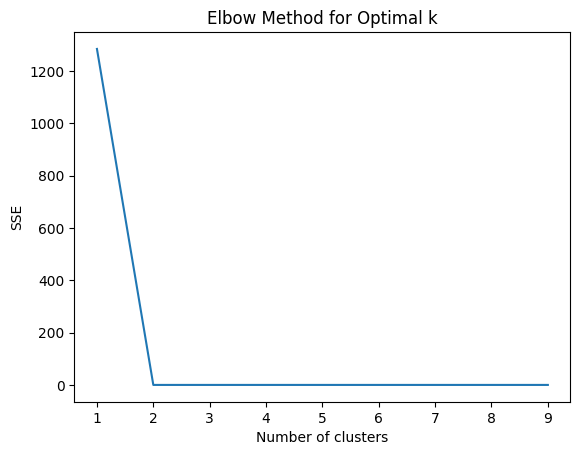

In [79]:
plot_sse_elbow(view_final, 'FREQUENCY')

In [80]:
view_final = perform_kmeans(view_final, 'FREQUENCY', 2, 'FrequencyCluster')
view_final = order_cluster('FrequencyCluster', 'FREQUENCY', view_final, True)
view_final.groupby('FrequencyCluster')['FREQUENCY'].describe()

,count,mean,std,min,25%,50%,75%,max
FrequencyCluster,,,,,,,,
0,14830.0,1.0,0.0,1.0,1.0,1.0,1.0,1.0
1,1407.0,2.0,0.0,2.0,2.0,2.0,2.0,2.0


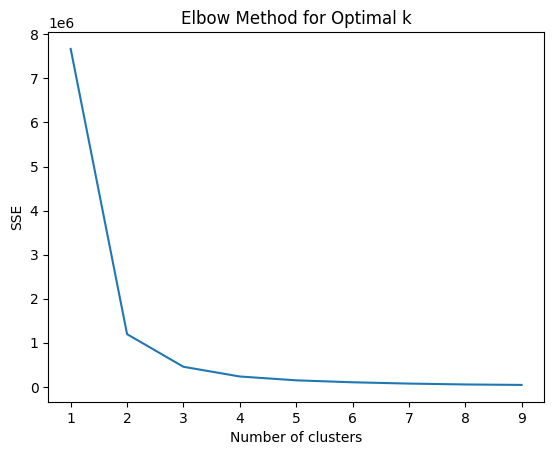

In [81]:
plot_sse_elbow(view_final, 'TENURE')

In [82]:
view_final = perform_kmeans(view_final, 'TENURE', 3, 'TenureCluster')
view_final = order_cluster('TenureCluster', 'TENURE', view_final, True)
view_final.groupby('TenureCluster')['TENURE'].describe()

,count,mean,std,min,25%,50%,75%,max
TenureCluster,,,,,,,,
0,15223.0,1.311568,2.295008,1.0,1.0,1.0,1.0,28.0
1,600.0,55.726667,16.998241,29.0,40.0,55.5,70.0,87.0
2,414.0,120.185990,22.085169,88.0,101.0,118.0,136.0,174.0


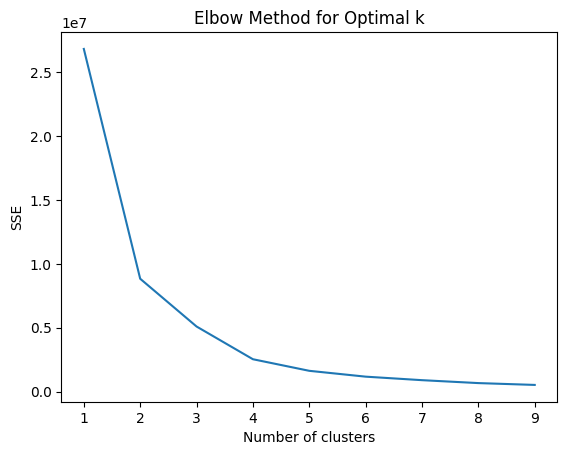

In [83]:
plot_sse_elbow(view_final, 'SUM_DURATION')

In [84]:
view_final = perform_kmeans(view_final, 'SUM_DURATION', 3, 'DurationCluster')
view_final = order_cluster('DurationCluster', 'SUM_DURATION', view_final, True)
view_final.groupby('DurationCluster')['SUM_DURATION'].describe()

,count,mean,std,min,25%,50%,75%,max
DurationCluster,,,,,,,,
0,5950.0,29.825630,13.551696,6.0,18.0,30.1,41.3,53.4
1,6086.0,76.819405,13.491409,53.5,65.2,76.9,88.4,100.0
2,4201.0,123.185527,26.252227,100.1,107.6,115.3,123.2,246.9


In [85]:
view_final['OverallScore'] = view_final['RecencyCluster'] + view_final['FrequencyCluster'] + view_final['TenureCluster'] + view_final['DurationCluster']
view_final.groupby('OverallScore')['RECENCY','FREQUENCY','TENURE','SUM_DURATION'].mean()

,RECENCY,FREQUENCY,TENURE,SUM_DURATION
OverallScore,,,,
0,147.466482,1.000000,1.000000,29.600942
1,117.802598,1.001130,1.006213,53.472635
2,71.022400,1.004800,1.062000,61.782220
3,45.668763,1.033243,1.540581,87.650105
4,34.300792,1.153034,5.334433,112.579024
5,50.652709,2.000000,47.145320,134.516010
6,30.414634,2.000000,76.254743,141.146341
7,22.061303,2.000000,122.494253,156.208429


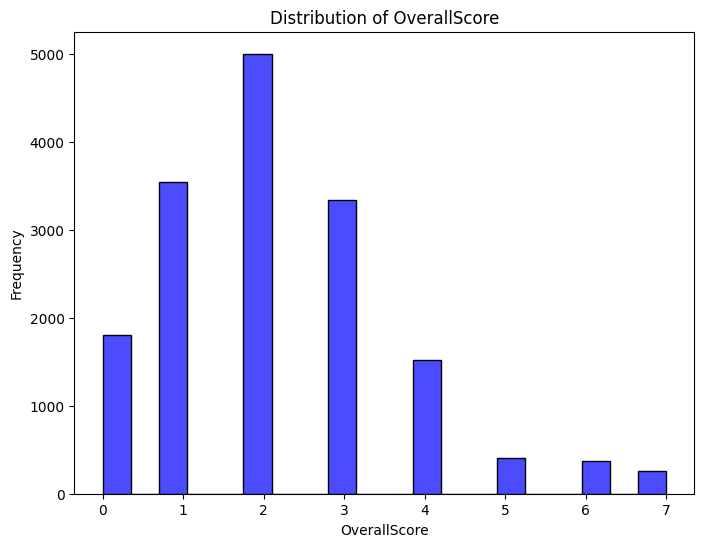

In [86]:
## Visualization
plt.figure(figsize=(8, 6))
sns.histplot(view_final['OverallScore'], kde=False, bins=20, color="blue", alpha = 0.7)
plt.title('Distribution of OverallScore')
plt.xlabel('OverallScore')
plt.ylabel('Frequency')
plt.show()

In [87]:
## add segments
view_final['Segment'] = 'Low-Value'
view_final.loc[view_final['OverallScore'] > 1, 'Segment'] = 'Mid-Value'
view_final.loc[view_final['OverallScore'] > 3, 'Segment'] = 'High-Value'

In [88]:
view_final

,ID,NETWORK,RECENCY,FREQUENCY,TENURE,SUM_DURATION,RecencyCluster,FrequencyCluster,TenureCluster,DurationCluster,OverallScore,Segment
0,000EFUI271,LimeLight,56,1,1,31.9,2,0,0,0,2,Mid-Value
1,000TFKR237,RetroReel,9,1,1,41.8,2,0,0,0,2,Mid-Value
2,001BZBX615,RetroReel,27,1,1,39.1,2,0,0,0,2,Mid-Value
3,001SIVU071,Pulse,31,1,1,49.6,2,0,0,0,2,Mid-Value
4,002FCKO341,RetroReel,20,1,1,26.2,2,0,0,0,2,Mid-Value
...,...,...,...,...,...,...,...,...,...,...,...,...
16232,233MRCQ963,Pulse,133,2,46,53.8,0,1,1,1,3,Mid-Value
16233,381XUOL927,RetroReel,140,2,31,92.5,0,1,1,1,3,Mid-Value
16234,443SITI810,LimeLight,118,2,48,86.8,0,1,1,1,3,Mid-Value
16235,466GFIN392,CineQuest,122,2,34,95.8,0,1,1,1,3,Mid-Value


In [89]:
# List of columns to rename
columns_to_rename = [
    'RECENCY', 'FREQUENCY', 'TENURE', 'SUM_DURATION',
    'RecencyCluster', 'FrequencyCluster', 'TenureCluster',
    'DurationCluster', 'OverallScore', 'Segment'
]

# Rename columns by appending '_View'
view_final.rename(columns={col: f"{col}_view" for col in columns_to_rename}, inplace=True)
view_final.rename(columns={'NETWORK': 'BRAND'}, inplace=True)

### Online Content Processing and Clustering

In [90]:
online_df = pd.read_csv('train_x_grouped.csv')
online_df = online_df[online_df.BRAND.isin(select_brand)]
online_df = online_df.drop(columns=['Unnamed: 0'])

# Renaming columns to uppercase
online_df.columns = [col.upper() for col in online_df.columns]
online_df['BRAND'].unique()

array(['RetroReel', 'CineQuest', 'LimeLight', 'Pulse', 'ChillStream'],
      dtype=object)

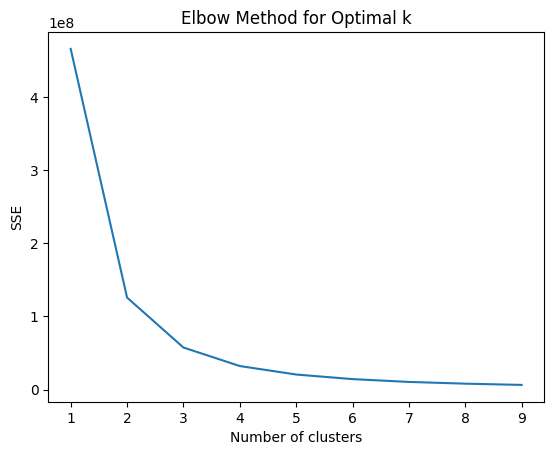

In [91]:
plot_sse_elbow(online_df, 'RECENCY')

In [92]:
online_df = perform_kmeans(online_df, 'RECENCY', 3, 'RecencyCluster')
online_df = order_cluster('RecencyCluster', 'RECENCY', online_df, False)
online_df.groupby('RecencyCluster')['RECENCY'].describe()

,count,mean,std,min,25%,50%,75%,max
RecencyCluster,,,,,,,,
0,10418.0,271.245633,44.357979,207.0,232.0,265.0,307.0,363.0
1,17608.0,142.168049,32.911430,92.0,113.0,139.0,169.0,206.0
2,26138.0,41.477121,26.258005,0.0,19.0,39.0,63.0,91.0


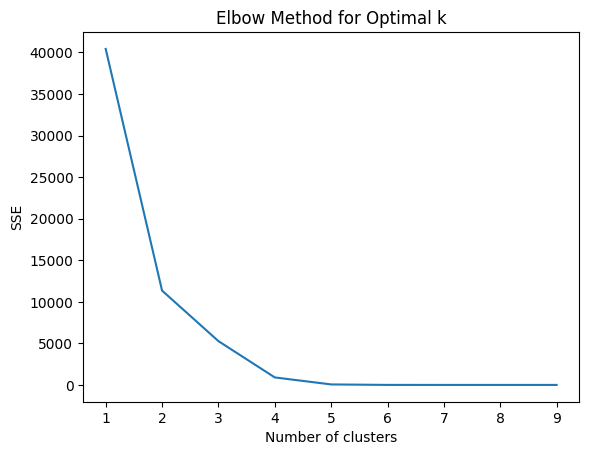

In [93]:
plot_sse_elbow(online_df, 'FREQUENCY')

In [94]:
online_df = perform_kmeans(online_df, 'FREQUENCY', 3, 'FrequencyCluster')
online_df = order_cluster('FrequencyCluster', 'FREQUENCY', online_df, True)
online_df.groupby('FrequencyCluster')['FREQUENCY'].describe()

,count,mean,std,min,25%,50%,75%,max
FrequencyCluster,,,,,,,,
0,30152.0,0.824323,0.380551,0.0,1.0,1.0,1.0,1.0
1,17741.0,2.000000,0.000000,2.0,2.0,2.0,2.0,2.0
2,6271.0,3.145591,0.379304,3.0,3.0,3.0,3.0,6.0


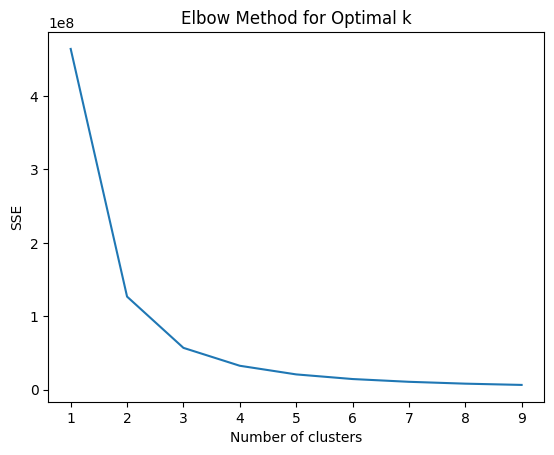

In [95]:
plot_sse_elbow(online_df, 'TENURE')

In [96]:
online_df = perform_kmeans(online_df, 'TENURE', 3, 'TenureCluster')
online_df = order_cluster('TenureCluster', 'TENURE', online_df, True)
online_df.groupby('TenureCluster')['TENURE'].describe()

,count,mean,std,min,25%,50%,75%,max
TenureCluster,,,,,,,,
0,10318.0,91.408025,44.287206,0.0,56.0,97.0,130.0,156.0
1,17657.0,221.081894,32.487584,157.0,195.0,224.0,249.0,271.0
2,26189.0,321.601627,26.245637,272.0,300.0,324.0,345.0,363.0


In [97]:
online_df['OverallScore'] = online_df['RecencyCluster'] + online_df['FrequencyCluster'] + online_df['TenureCluster']
online_df.groupby('OverallScore')['RECENCY','FREQUENCY','TENURE'].mean()

,RECENCY,FREQUENCY,TENURE
OverallScore,,,
1,180.187939,0.676717,183.458455
2,166.697643,0.815243,196.641445
3,116.174280,1.443895,247.726506
4,82.417110,1.822278,280.904655
5,55.539057,2.357215,307.457012
6,38.756502,3.181404,323.894668


In [98]:
## add segments
online_df['Segment'] = 'Low-Value'
online_df.loc[online_df['OverallScore'] > 2, 'Segment'] = 'Mid-Value'
online_df.loc[online_df['OverallScore'] > 4, 'Segment'] = 'High-Value'

In [99]:
# List of columns to rename
columns_to_rename = [
    'RECENCY', 'FREQUENCY', 'TENURE',
    'RecencyCluster', 'FrequencyCluster', 'TenureCluster',
    'OverallScore', 'Segment'
]

# Rename columns by appending '_View'
online_df.rename(columns={col: f"{col}_online" for col in columns_to_rename}, inplace=True)

# join with viewership data
view_online = pd.merge(online_df, view_final, on=['ID', 'BRAND'], how='inner')

### Subscription Processing and Clustering

In [100]:
sub_df = pd.read_csv('sub_2023_first_6m_rfm.csv')
sub_df = sub_df.drop(columns=['Unnamed: 0', 'SUB', 'DATE'])
sub_df = sub_df[sub_df.BRAND.isin(select_brand)]

# List of columns to rename
columns_to_rename = [
    'RECENCY', 'FREQUENCY', 'REVENUE'
]
# Rename columns by appending '_sub'
sub_df.rename(columns={col: f"{col}_sub" for col in columns_to_rename}, inplace=True)
sub_df

,ID,BRAND,RECENCY_sub,REVENUE_sub,FREQUENCY_sub
0,000AHHU956,RetroReel,0,216.418272,1
1,000BRHY264,CineQuest,0,37.448276,1
2,000DJKK225,CineQuest,0,71.408219,1
3,000EFUI271,LimeLight,0,39.676192,1
4,000ELOE240,LimeLight,66,0.000000,1
...,...,...,...,...,...
43764,999WMMD928,LimeLight,0,39.671233,1
43765,999WVJU110,Pulse,0,73.377553,1
43766,999ZGDS170,CineQuest,120,60.000000,1
43767,999ZIAU985,RetroReel,0,178.580055,1


In [101]:
# join with online content and viewership data
view_online_sub = pd.merge(view_online, sub_df, on=['ID','BRAND'], how='inner')

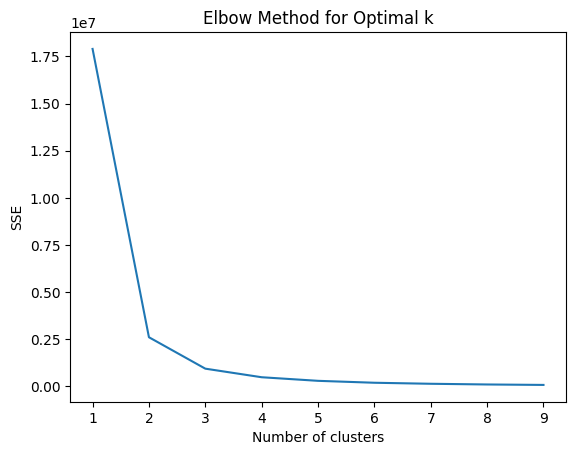

In [102]:
plot_sse_elbow(view_online_sub, 'RECENCY_sub')

In [103]:
view_online_sub = perform_kmeans(view_online_sub, 'RECENCY_sub', 3, 'RecencyCluster_sub')
view_online_sub = order_cluster('RecencyCluster_sub', 'RECENCY_sub', view_online_sub, False)
view_online_sub.groupby('RecencyCluster_sub')['RECENCY_sub'].describe()

,count,mean,std,min,25%,50%,75%,max
RecencyCluster_sub,,,,,,,,
0,753.0,141.606906,21.741397,106.0,122.0,140.0,161.0,180.0
1,944.0,69.415254,20.096829,36.0,53.0,68.0,87.0,105.0
2,10469.0,0.884134,4.453668,0.0,0.0,0.0,0.0,35.0


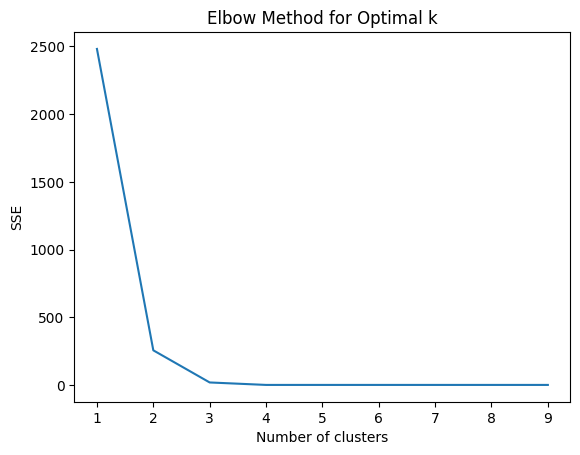

In [104]:
plot_sse_elbow(view_online_sub, 'FREQUENCY_sub')

In [105]:
view_online_sub = perform_kmeans(view_online_sub, 'FREQUENCY_sub', 2, 'FrequencyCluster_sub')
view_online_sub = order_cluster('FrequencyCluster_sub', 'FREQUENCY_sub', view_online_sub, True)
view_online_sub.groupby('FrequencyCluster_sub')['FREQUENCY_sub'].describe()

,count,mean,std,min,25%,50%,75%,max
FrequencyCluster_sub,,,,,,,,
0,9957.0,1.000000,0.000000,1.0,1.0,1.0,1.0,1.0
1,2209.0,2.109552,0.340162,2.0,2.0,2.0,2.0,4.0


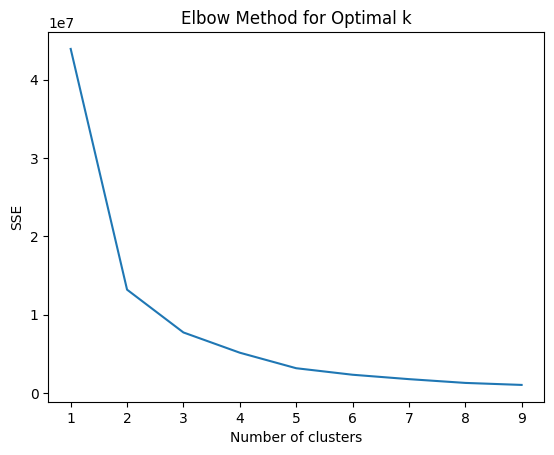

In [106]:
plot_sse_elbow(view_online_sub, 'REVENUE_sub')

In [107]:
view_online_sub = perform_kmeans(view_online_sub, 'REVENUE_sub', 3, 'RevenueCluster_sub')
view_online_sub = order_cluster('RevenueCluster_sub', 'REVENUE_sub', view_online_sub, True)
view_online_sub.groupby('RevenueCluster_sub')['REVENUE_sub'].describe()

,count,mean,std,min,25%,50%,75%,max
RevenueCluster_sub,,,,,,,,
0,7128.0,41.460929,20.341767,0.000000,25.556433,41.380144,58.617545,79.035784
1,3450.0,116.744817,21.148368,79.047636,100.000000,119.013699,129.754939,155.848388
2,1588.0,195.107879,45.217621,155.950000,178.084713,178.580055,193.526192,608.080000


In [108]:
view_online_sub['OverallScore_sub'] = view_online_sub['RecencyCluster_sub'] + view_online_sub['FrequencyCluster_sub'] + view_online_sub['RevenueCluster_sub']
view_online_sub.groupby('OverallScore_sub')['RECENCY_sub','FREQUENCY_sub','REVENUE_sub'].mean()

,RECENCY_sub,FREQUENCY_sub,REVENUE_sub
OverallScore_sub,,,
0,142.818763,1.000000,26.554307
1,99.391304,1.238261,49.684487
2,6.828073,1.030459,47.325858
3,4.498086,1.351285,98.642298
4,1.830189,1.346282,170.474811
5,1.495283,2.127358,194.135964


In [109]:
## add segments
view_online_sub['Segment_sub'] = 'Low-Value'
view_online_sub.loc[view_online_sub['OverallScore_sub'] > 1, 'Segment_sub'] = 'Mid-Value'
view_online_sub.loc[view_online_sub['OverallScore_sub'] > 3, 'Segment_sub'] = 'High-Value'

In [110]:
view_online_sub['Final_Score'] = view_online_sub['OverallScore_online'] + view_online_sub['OverallScore_view'] + 2 * view_online_sub['OverallScore_sub']
view_online_sub

,ID,BRAND,RECENCY_online,FREQUENCY_online,TENURE_online,RecencyCluster_online,FrequencyCluster_online,TenureCluster_online,OverallScore_online,Segment_online,...,Segment_view,RECENCY_sub,REVENUE_sub,FREQUENCY_sub,RecencyCluster_sub,FrequencyCluster_sub,RevenueCluster_sub,OverallScore_sub,Segment_sub,Final_Score
0,000QEVH452,LimeLight,208,1,208,0,0,1,1,Low-Value,...,Mid-Value,0,15.506608,1,2,0,0,2,Mid-Value,8
1,004ZVVX124,CineQuest,252,1,265,0,0,1,1,Low-Value,...,High-Value,0,41.255914,1,2,0,0,2,Mid-Value,9
2,008EJGC563,CineQuest,225,1,225,0,0,1,1,Low-Value,...,Low-Value,0,19.681943,1,2,0,0,2,Mid-Value,5
3,008WMEQ926,Pulse,230,0,230,0,0,1,1,Low-Value,...,Mid-Value,0,24.662694,1,2,0,0,2,Mid-Value,8
4,011RJQJ064,LimeLight,269,1,269,0,0,1,1,Low-Value,...,Low-Value,0,7.942113,1,2,0,0,2,Mid-Value,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12161,596SKOJ628,RetroReel,51,1,140,2,0,0,2,Low-Value,...,Mid-Value,93,90.000000,2,1,1,1,3,Mid-Value,10
12162,681PEXN433,RetroReel,12,1,12,2,0,0,2,Low-Value,...,Mid-Value,66,90.000000,3,1,1,1,3,Mid-Value,11
12163,921LATG602,ChillStream,74,1,151,2,0,0,2,Low-Value,...,Low-Value,98,88.930000,2,1,1,1,3,Mid-Value,9
12164,081VZDE948,CineQuest,128,2,139,1,1,0,2,Low-Value,...,Mid-Value,99,95.970000,2,1,1,1,3,Mid-Value,10


In [111]:
view_online_sub.groupby('Final_Score')['RECENCY_view', 'FREQUENCY_view', 'TENURE_view', 'SUM_DURATION_view',
                                       'RECENCY_online', 'FREQUENCY_online', 'TENURE_online',
                                       'RECENCY_sub', 'REVENUE_sub', 'FREQUENCY_sub'].mean()

,RECENCY_view,FREQUENCY_view,TENURE_view,SUM_DURATION_view,RECENCY_online,FREQUENCY_online,TENURE_online,RECENCY_sub,REVENUE_sub,FREQUENCY_sub
Final_Score,,,,,,,,,,
1,145.600000,1.000000,1.000000,22.520000,154.800000,0.400000,165.200000,151.200000,12.982000,1.000000
2,137.500000,1.000000,1.000000,47.375000,198.916667,0.750000,211.791667,142.458333,30.895833,1.000000
3,99.400000,1.000000,1.000000,46.661818,171.109091,0.781818,204.218182,134.000000,30.340182,1.036364
4,106.247423,1.000000,1.000000,49.005155,124.051546,1.113402,204.845361,134.329897,33.856804,1.092784
5,107.338028,1.014085,1.267606,51.819249,151.408451,1.061033,203.305164,89.455399,41.863293,1.093897
6,112.559252,1.006237,1.176715,49.832848,155.004158,1.010395,219.128898,53.721414,42.180958,1.068607
7,106.173544,1.010922,1.379854,54.974757,151.581311,1.061893,218.691748,29.354369,48.004680,1.070388
8,94.670712,1.009709,1.256472,56.826618,142.033981,1.162621,225.389968,18.616505,55.335277,1.095469
9,86.887446,1.021645,1.567718,64.273098,126.205318,1.296846,229.829314,11.933210,63.099363,1.115028


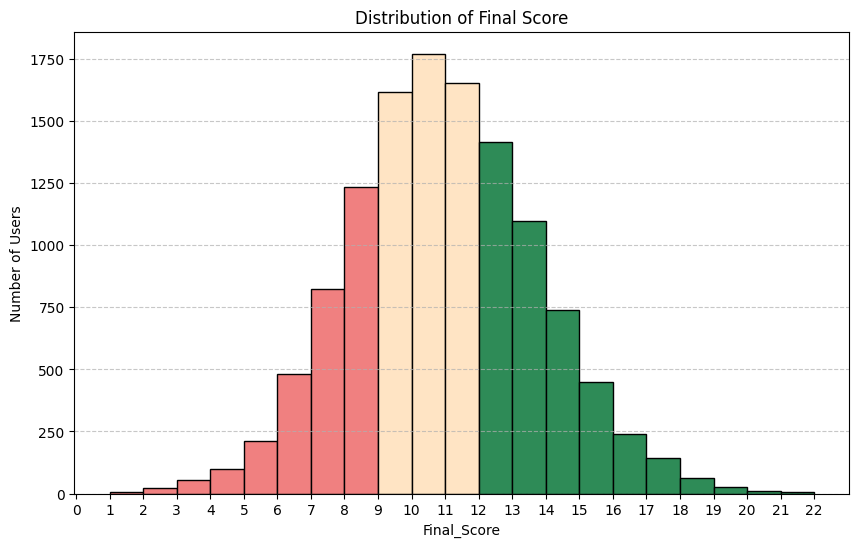

In [112]:
final_score = view_online_sub['Final_Score']

# Define bin edges
bins = np.arange(1, 23, 1)  

# Create the histogram
plt.figure(figsize=(10, 6))
n, edges, patches = plt.hist(final_score, bins=bins, edgecolor='black')

# Assign colors based on conditions
for patch, left_edge in zip(patches, edges[:-1]):
    if left_edge < 9:
        patch.set_facecolor('lightcoral')
    elif 9 <= left_edge <= 11:
        patch.set_facecolor('bisque')
    else:
        patch.set_facecolor('seagreen')

# Add labels and grid
plt.title('Distribution of Final Score')
plt.xlabel('Final_Score')
plt.ylabel('Number of Users')
plt.xticks(range(0, 23))
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Display the plot
plt.show()


In [113]:
## add segments
view_online_sub['Final_Segment'] = 'Low-Value'
view_online_sub.loc[view_online_sub['Final_Score'] > 8, 'Final_Segment'] = 'Mid-Value'
view_online_sub.loc[view_online_sub['Final_Score'] > 11, 'Final_Segment'] = 'High-Value'

In [114]:
view_online_sub.Final_Segment.value_counts()

Mid-Value     5039
High-Value    4192
Low-Value     2935
Name: Final_Segment, dtype: int64

In [115]:
result = view_online_sub.groupby('Final_Segment')[['RECENCY_view', 'TENURE_view', 'SUM_DURATION_view',
                                                   'RECENCY_online', 'FREQUENCY_online',
                                                   'RECENCY_sub', 'REVENUE_sub']].mean()
result = result.rename(columns={'REVENUE_sub': 'Monetary Value'}).sort_values(by='Monetary Value')

result


,RECENCY_view,TENURE_view,SUM_DURATION_view,RECENCY_online,FREQUENCY_online,RECENCY_sub,Monetary Value
Final_Segment,,,,,,,
Low-Value,102.659284,1.263032,54.212436,147.957751,1.088586,39.750256,48.693496
Mid-Value,79.834094,2.384600,67.270907,117.474300,1.457630,9.134551,74.281106
High-Value,60.118082,14.093273,88.424284,89.075620,1.897424,4.465172,117.107951


In [116]:
result = view_online_sub.groupby('Final_Segment')[['SUM_DURATION_view',
                                                   'RECENCY_online',
                                                   'REVENUE_sub']].mean()
result = result.rename(columns={'REVENUE_sub': 'Monetary Value'}).sort_values(by='Monetary Value')

result

,SUM_DURATION_view,RECENCY_online,Monetary Value
Final_Segment,,,
Low-Value,54.212436,147.957751,48.693496
Mid-Value,67.270907,117.474300,74.281106
High-Value,88.424284,89.075620,117.107951


### LTV Data Processing (next 6 months)

In [117]:
### LTV for next 6 month
ltv_df = pd.read_csv('dropna_2023_last_6m_rev.csv')
ltv_df = ltv_df.drop(columns=['Unnamed: 0', 'SUB_DETAIL', 'AMOUNT', 'START_DATE', 'END_DATE', 'DURATION'])
ltv_df = ltv_df.rename(columns={'REVENUE': 'LTV'})
ltv_df = ltv_df[ltv_df.BRAND.isin(select_brand)]
ltv_df = ltv_df.groupby(['ID','BRAND']).sum('LTV')
ltv_df

,,LTV
ID,BRAND,
000AHHU956,RetroReel,165.841728
000BRHY264,CineQuest,22.551724
000DJKK225,CineQuest,72.591781
000DTPC747,LimeLight,80.000000
000EFUI271,LimeLight,40.333808
...,...,...
999WJDL067,ChillStream,151.293370
999WMMD928,LimeLight,40.328767
999WVJU110,Pulse,54.622447


In [118]:
df_final = pd.merge(view_online_sub, ltv_df, on=['ID','BRAND'], how='left')
df_final['LTV'] = df_final['LTV'].fillna(0)

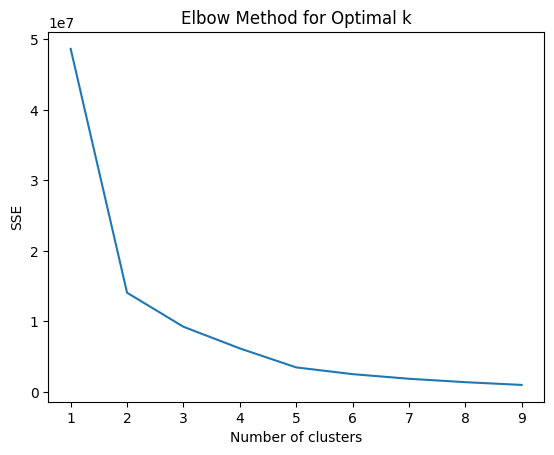

In [119]:
plot_sse_elbow(df_final, 'LTV')

In [120]:
df_final = perform_kmeans(df_final, 'LTV', 3, 'LTVCluster')
df_final = order_cluster('LTVCluster', 'LTV', df_final, True)
df_final.groupby('LTVCluster')['LTV'].describe()

,count,mean,std,min,25%,50%,75%,max
LTVCluster,,,,,,,,
0,7636.0,42.928626,23.298703,0.000000,26.927143,47.708404,60.488110,84.348664
1,2860.0,125.998902,19.205544,84.435144,120.000000,123.022593,138.876468,161.542377
2,1670.0,197.467976,49.160041,161.648007,181.418959,181.539945,196.602740,609.162222


In [121]:
df_final.groupby('Final_Segment')['LTV'].mean()

Final_Segment
High-Value    103.282077
Low-Value      61.999148
Mid-Value      79.977257
Name: LTV, dtype: float64

### Classification Model
Xgboost classification (3 classes)

In [122]:
# One hot encoding
df_final_dummy = pd.get_dummies(df_final, columns=['Segment_view', 'Segment_online', 'Segment_sub', 'Final_Segment'], dtype='int')
corr_matrix = df_final_dummy.corr()
corr_matrix['LTVCluster'].sort_values(ascending=False)

LTVCluster                   1.000000
LTV                          0.899420
RevenueCluster_sub           0.560326
REVENUE_sub                  0.501982
Segment_sub_High-Value       0.446358
OverallScore_sub             0.441529
Final_Score                  0.298955
Final_Segment_High-Value     0.259541
RecencyCluster_sub           0.125005
Segment_online_Low-Value     0.027464
RECENCY_online               0.011481
Segment_view_Mid-Value       0.010941
SUM_DURATION_view            0.008838
DurationCluster_view         0.007273
OverallScore_view            0.001322
TENURE_view                  0.000960
RECENCY_view                 0.000751
FrequencyCluster_view       -0.000956
FREQUENCY_view              -0.000956
TenureCluster_view          -0.001090
RecencyCluster_view         -0.003754
Segment_view_High-Value     -0.004466
Segment_online_High-Value   -0.006433
RecencyCluster_online       -0.006890
Segment_view_Low-Value      -0.008191
TenureCluster_online        -0.011042
TENURE_onlin

In [123]:
X = df_final_dummy.drop(['LTVCluster','LTV', 'ID', 'BRAND'], axis=1)
y = df_final_dummy['LTVCluster']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=21)

Use class weights to make the data more balanced

Use grid search to find the best model parameters

In [124]:
# Compute weights inversely proportional to frequency:
class_counts = y_train.value_counts()
total = len(y_train)

class_weights = {cls: total/(len(class_counts)*count) for cls, count in class_counts.items()}

# Create a weight array
sample_weights = y_train.map(class_weights)

# Define a parameter grid for max_depth and learning_rate
param_grid = {
    'max_depth': [3, 5],        
    'learning_rate': [0.01, 0.05, 0.1],
    'n_estimators': [100, 300]
}

# Initialize the model (with other desired fixed parameters)
xgb_model = xgb.XGBClassifier(
    objective='multi:softprob', 
    n_jobs=-1, 
    min_child_weight = 1,
    random_state = seed
)

# Set up GridSearchCV
# Use fit_params to pass sample_weight to model's fit method
grid_search = GridSearchCV(
    estimator=xgb_model,
    param_grid=param_grid,
    scoring='accuracy',  
    cv=5,                  # 5-fold cross-validation
    n_jobs=-1,
    verbose=1,
)

# Perform the grid search
grid_search.fit(X_train, y_train, **{'sample_weight': sample_weights})

# Print the best parameters and best score
print("Best parameters found: ", grid_search.best_params_)
print("Best cross-validation score: ", grid_search.best_score_)

Fitting 5 folds for each of 12 candidates, totalling 60 fits
Best parameters found:  {'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 300}
Best cross-validation score:  0.7669546159242537


In [125]:
# Refit model with the best parameters
best_model = grid_search.best_estimator_

# Evaluate on training and test sets
train_acc = best_model.score(X_train, y_train)
test_acc = best_model.score(X_test[X_train.columns], y_test)

print('Accuracy of XGB classifier on training set: {:.2f}'.format(train_acc))
print('Accuracy of XGB classifier on test set: {:.2f}'.format(test_acc))

Accuracy of XGB classifier on training set: 0.77
Accuracy of XGB classifier on test set: 0.77


In [126]:
y_pred = best_model.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.84      0.89      0.86      1563
           1       0.63      0.57      0.60       514
           2       0.63      0.57      0.60       357

    accuracy                           0.77      2434
   macro avg       0.70      0.68      0.69      2434
weighted avg       0.77      0.77      0.77      2434



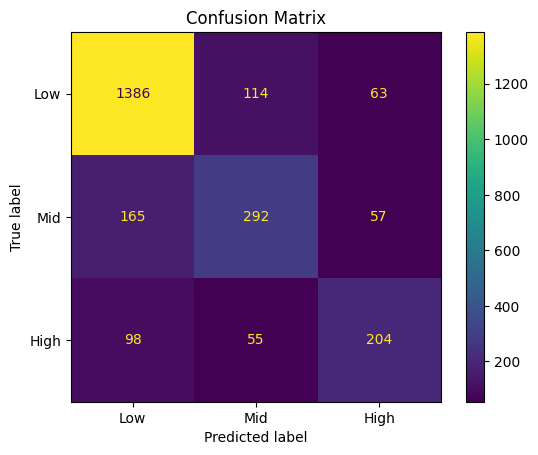

In [127]:
# Plot confusion matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Low', 'Mid', 'High'])
disp.plot()
plt.title("Confusion Matrix")
plt.show()

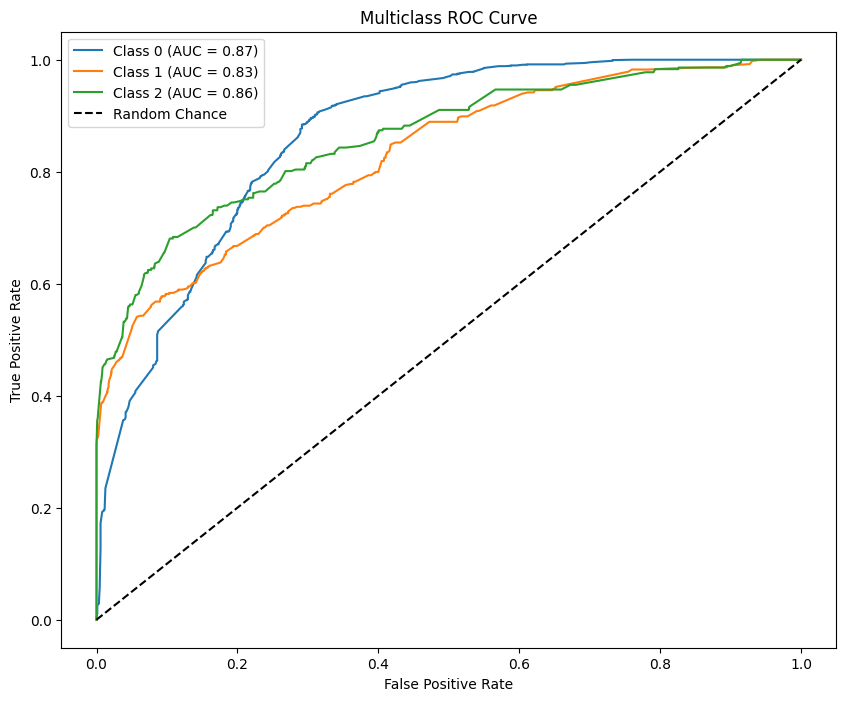

In [128]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
from sklearn.multiclass import OneVsRestClassifier
from sklearn.metrics import RocCurveDisplay

# Binarize the labels for ROC calculation
classes = list(set(y_train))  # Unique classes
y_train_bin = label_binarize(y_train, classes=classes)
y_test_bin = label_binarize(y_test, classes=classes)

# Fit the best model (assumed to be already refit)
y_score_train = best_model.predict_proba(X_train)
y_score_test = best_model.predict_proba(X_test[X_train.columns])

# Plot ROC curve for each class
plt.figure(figsize=(10, 8))
for i, class_label in enumerate(classes):
    # Compute ROC curve and AUC for the class
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score_test[:, i])
    roc_auc = auc(fpr, tpr)
    
    # Plot the ROC curve
    plt.plot(fpr, tpr, label=f"Class {class_label} (AUC = {roc_auc:.2f})")

# Plot the baseline (random chance)
plt.plot([0, 1], [0, 1], 'k--', label='Random Chance')

# Add labels, title, legend, and display the plot
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Multiclass ROC Curve')
plt.legend(loc="best")
plt.show()

### Feature Analysis (Shapley Values)

In [129]:
# Initialize the SHAP explainer with your model
explainer = shap.TreeExplainer(best_model)

# Compute SHAP values for the test set
shap_values = explainer(X_test)

print("SHAP values shape:", shap_values.values.shape)

SHAP values shape: (2434, 36, 3)



Beeswarm Plot for Class 0:


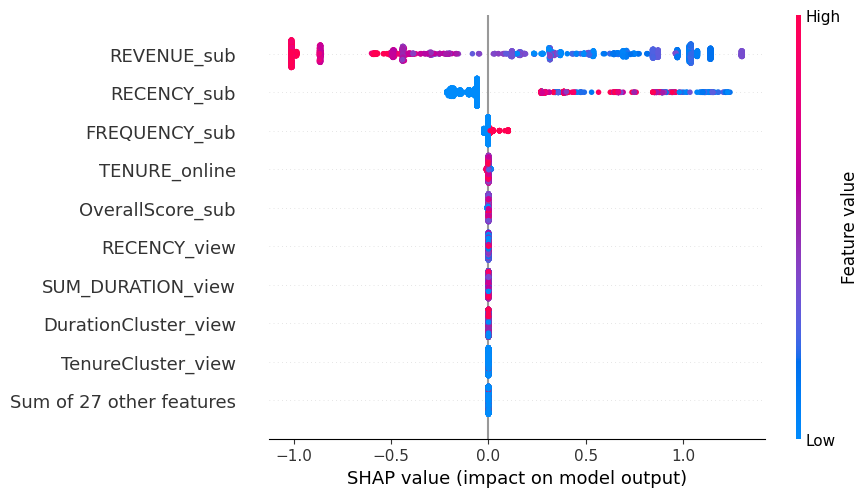


Beeswarm Plot for Class 1:


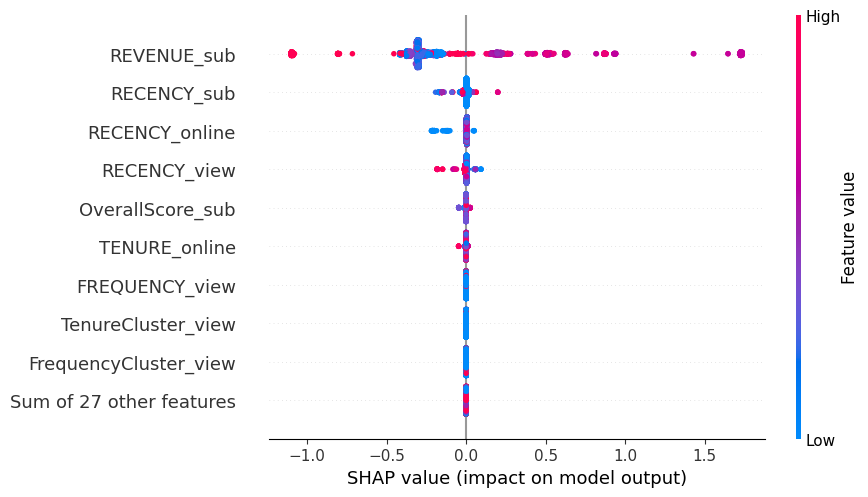


Beeswarm Plot for Class 2:


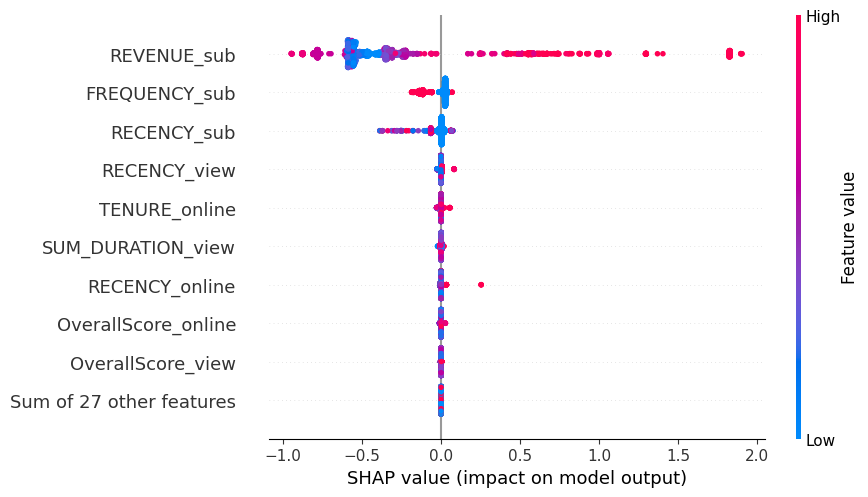

In [130]:
num_classes = shap_values.values.shape[2]

for class_idx in range(num_classes):
    print(f"\nBeeswarm Plot for Class {class_idx}:")
    
    shap_values_class = shap.Explanation(
        values=shap_values.values[:, :, class_idx],
        base_values=shap_values.base_values[:, class_idx],
        data=shap_values.data,
        feature_names=shap_values.feature_names
    )
    
    shap.plots.beeswarm(shap_values_class)

### Shapley Analysis
- REVENUE_sub:
This feature has the highest impact on the model's output across all three classes, as indicated by its prominent position and wide spread of SHAP values.

High values of REVENUE_sub (red) generally increase the prediction probability for mid/high class, and decrease the prob for low class.

- RECENCY_sub:
It is consistently ranked as one of the top features for all classes. However, its impact varies in magnitude and distribution:

Low values of RECENCY_sub decrease the prob for low class, but increase the prob for mid/high class.



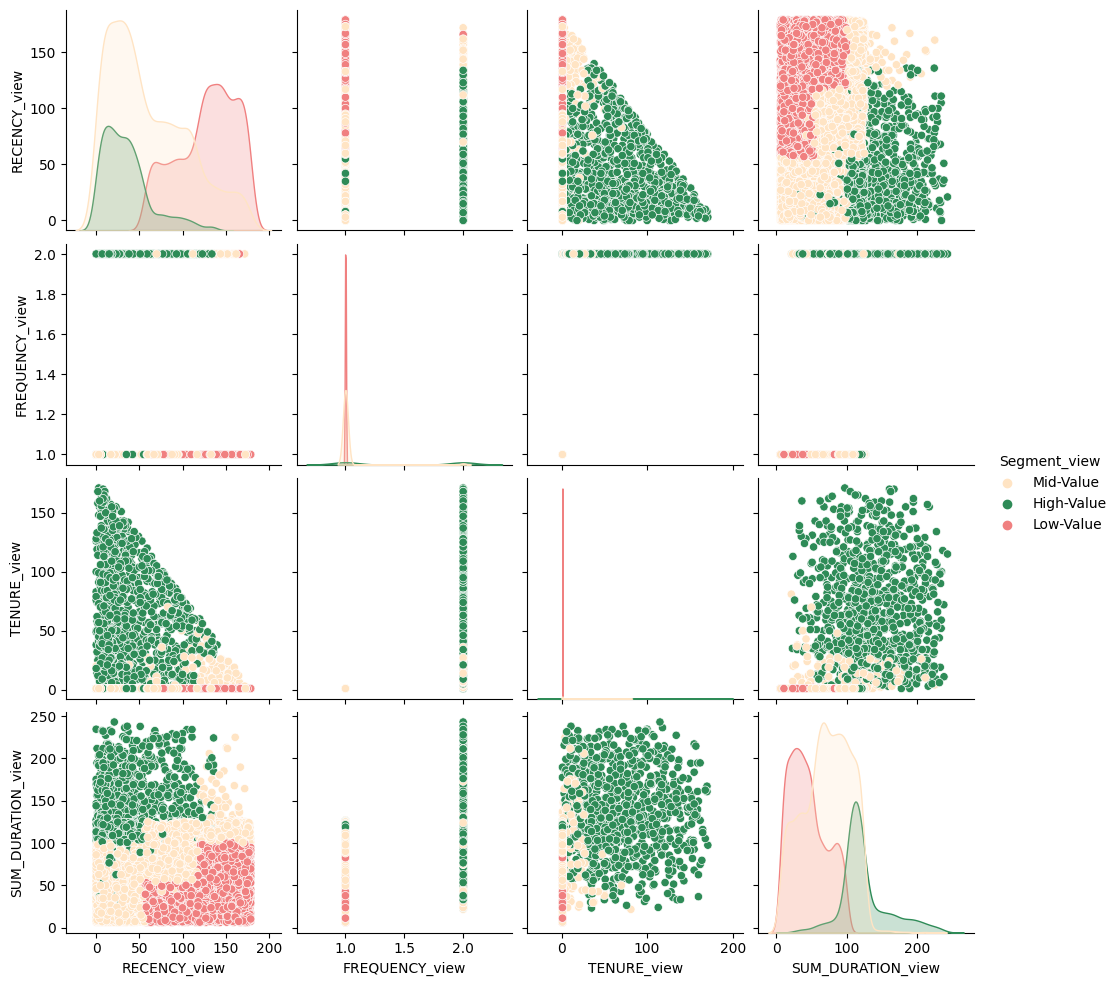

In [131]:
sns.pairplot(df_final, vars=['RECENCY_view', 'FREQUENCY_view', 'TENURE_view', 'SUM_DURATION_view'], hue='Segment_view', palette=color_palette)
plt.show()

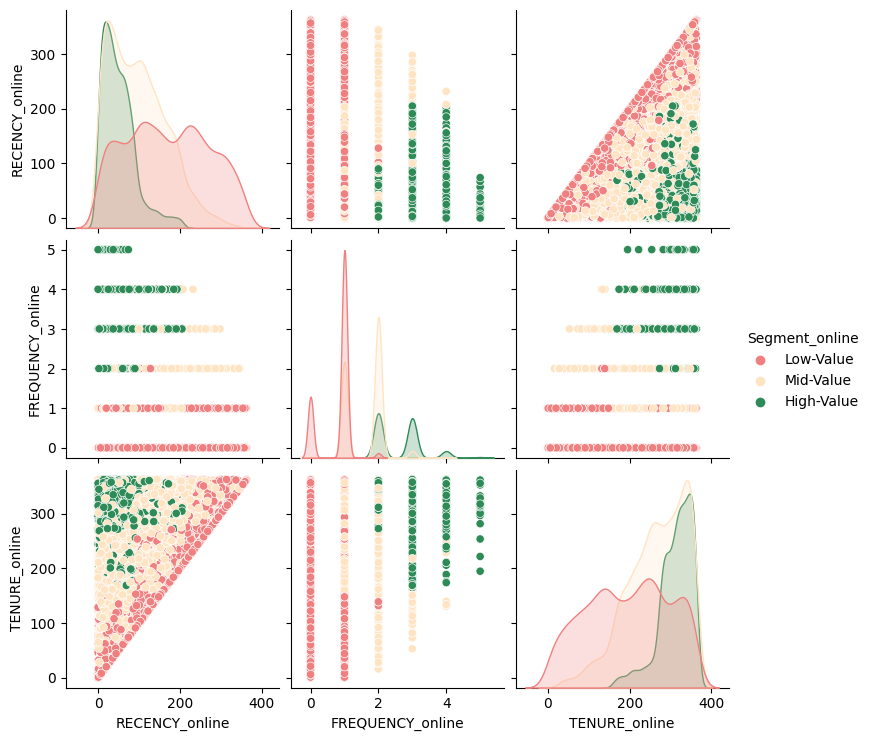

In [132]:
sns.pairplot(df_final, vars=['RECENCY_online', 'FREQUENCY_online', 'TENURE_online'], hue='Segment_online', palette=color_palette)
plt.show()

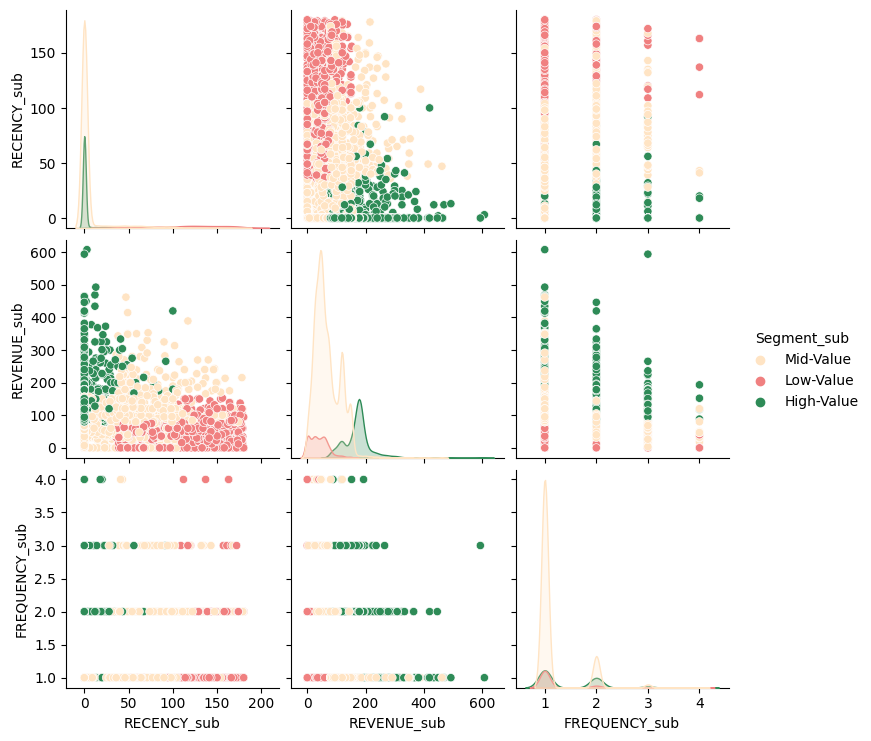

In [133]:
sns.pairplot(df_final, vars=['RECENCY_sub', 'REVENUE_sub', 'FREQUENCY_sub'], hue='Segment_sub', palette=color_palette)
plt.show()

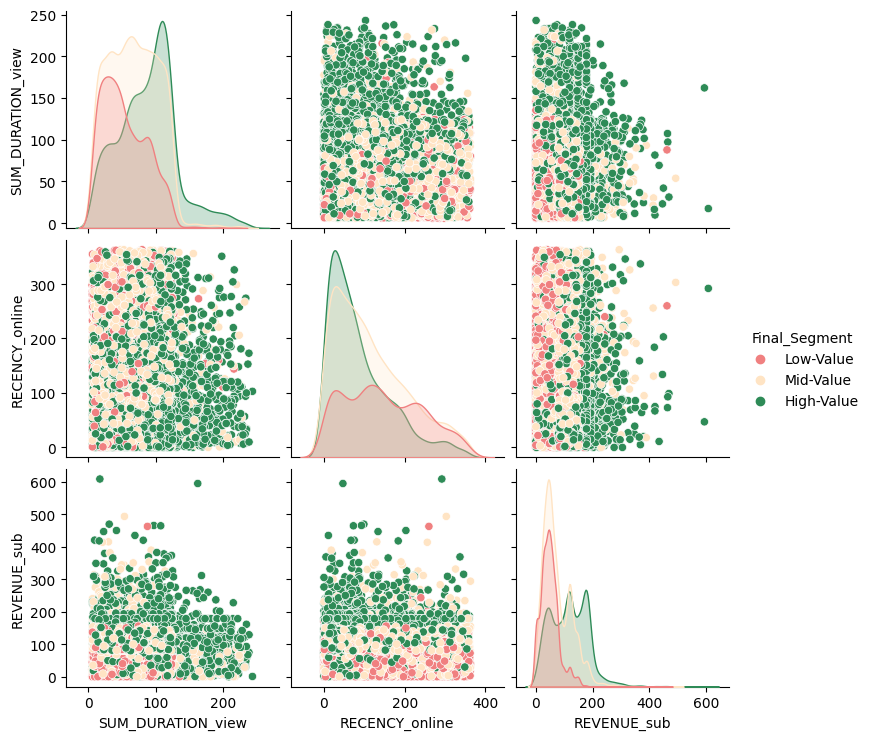

In [134]:
sns.pairplot(df_final, vars=['SUM_DURATION_view', 'RECENCY_online', 'REVENUE_sub'], hue='Final_Segment', palette=color_palette)
plt.show()

In [135]:
segment_ids = df_final.groupby("Final_Segment").agg({
    "ID": list,
    "BRAND": list
}).reset_index()

segment_ids.to_csv('2023_first_6m_seg.csv')
df_final.to_csv('df_russell_model.csv')

---------------------------------------------------
## Viewership Segment Analysis

In [136]:
df_final.Final_Segment.value_counts()

Mid-Value     5039
High-Value    4192
Low-Value     2935
Name: Final_Segment, dtype: int64

In [137]:
# Each row represents a customer or record associated with a Final_Segment and an LTV_cluster
mapping = {0: "Low-LTV", 1: "Mid-LTV", 2: "High-LTV"}
df_final2 = df_final.copy()
df_final2['LTVCluster'] = df_final2['LTVCluster'].map(mapping)

# Count how many records go from each Final_Segment to each LTV_cluster
flow_data = df_final2.groupby(['Final_Segment', 'LTVCluster']).size().reset_index(name='count')

final_segments = ["High-Value", "Mid-Value", "Low-Value"]
ltv_clusters = ["High-LTV", "Mid-LTV", "Low-LTV"]

# Create lists of all nodes: first the Final_Segment nodes, then the LTV_cluster nodes
all_nodes = final_segments + ltv_clusters

# Create dictionaries for node indices
node_indices = {node: i for i, node in enumerate(all_nodes)}

link_colors = (
    ["rgba(34,139,34,0.5)"] * 3   # first three chartreuse
    + ["rgba(255,165,0,0.5)"] * 3  # mid three orange
    + ["rgba(240,128,128,0.5)"] * 3  # last three light red (lightcoral)
)

# Prepare source, target, and value lists for the Sankey diagram
source = []
target = []
value = []

for seg in final_segments:
    seg_data = flow_data[flow_data['Final_Segment'] == seg]
    total = seg_data['count'].sum()
    if total > 0:
        for ltv in ltv_clusters:
            flow_count = seg_data[seg_data['LTVCluster'] == ltv]['count'].sum()
            if flow_count > 0:
                # Calculate percentage if you want percentages instead of counts
                # percentage = (flow_count / total) * 100
                # Use percentage or flow_count depending on preference
                percentage = (flow_count / total) * 100

                source.append(node_indices[seg])
                target.append(node_indices[ltv])
                value.append(percentage)  # or flow_count

# Create the Sankey figure
fig = go.Figure(data=[go.Sankey(
    arrangement="snap",
    node=dict(
        pad=15,
        thickness=20,
        line=dict(color="black", width=0.5),
        label=all_nodes,
        color=['seagreen', 'bisque', 'lightcoral', 'seagreen', 'bisque', 'lightcoral']
    ),
    link=dict(
        source=source,  # indices of source nodes
        target=target,  # indices of target nodes
        value=value,    # flow values (percentages or counts)
        color=link_colors
    )
)])

fig.update_layout(
    title_text="Flow from Final_Segment to LTV Cluster", 
    font_size=12,
    width=800,    # set the width in pixels
    height=600    # set the height in pixels
)
fig.show()


**Note**: Mid-value group has the most users, we can consider adjust the threshold.

### RFM Analysis

In [138]:
df_final['Final_Segment'] = pd.Categorical(
    df_final['Final_Segment'], 
    categories=['High-Value', 'Mid-Value', 'Low-Value'], 
    ordered=True
)

df_summary = df_final.groupby('Final_Segment')[['RECENCY_view', 'FREQUENCY_view', 'TENURE_view', 'SUM_DURATION_view']].mean()
df_summary

,RECENCY_view,FREQUENCY_view,TENURE_view,SUM_DURATION_view
Final_Segment,,,,
High-Value,60.118082,1.193225,14.093273,88.424284
Mid-Value,79.834094,1.036912,2.384600,67.270907
Low-Value,102.659284,1.009199,1.263032,54.212436


For high-value group, the users have the lowest Recency, the highest Frequency (number of views), longest tenure, and longest total watch time.

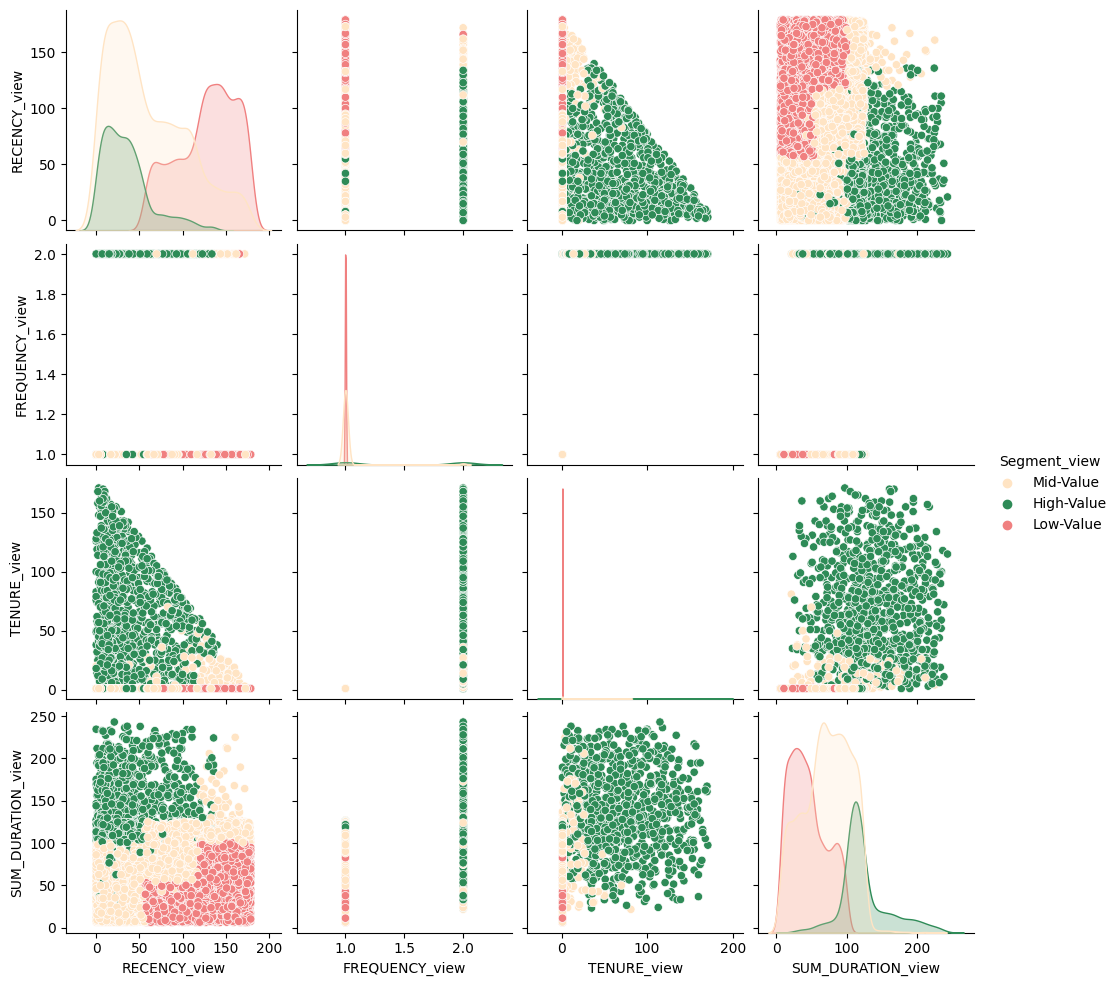

In [139]:
sns.pairplot(df_final, vars=['RECENCY_view', 'FREQUENCY_view', 'TENURE_view', 'SUM_DURATION_view'], hue='Segment_view', palette=color_palette)
plt.show()

### Brand Analysis

In [140]:
# join viewership data and the final segment for further analysis
view_seg = view_filtered.merge(df_final[['ID', 'Final_Segment']], on='ID', how='inner')
view_seg

,ID,NETWORK,PROGRAM_NAME,GENRE,EVENT_START_TIMESTAMP,NETWORK_TYPE,DURATION_MINUTES,AD_REVENUE,Final_Segment
0,561DIKT893,LimeLight,Extreme Makeovers: House Flips,"Lifestyle, Entertainment",2023-01-25 08:06:17,LINEAR,64.4,0.268264,Mid-Value
1,867YIQA894,LimeLight,Style Seekers: Global Trends,Reality-TV,2023-06-13 23:21:28,LINEAR,56.8,0.236667,High-Value
2,832CMFG402,RetroReel,The Big Picture: Cinema’s Finest Years,Other,2023-03-29 00:10:01,LINEAR,93.8,0.390764,Low-Value
3,832CMFG402,RetroReel,Hollywood Gold: The Best of the Silver Screen,Classic films,2023-02-24 07:53:32,LINEAR,62.3,0.259653,Low-Value
4,203DMJV669,Pulse,Stormfront: The Final Mission,Action,2023-06-01 04:43:25,LINEAR,52.5,0.218889,Mid-Value
...,...,...,...,...,...,...,...,...,...
16005,513CDBG679,ChillStream,Nomads of the North: Life in the Arctic,Documentary,2023-06-29 18:54:18,LINEAR,51.6,0.215139,High-Value
16006,629GRGN867,CineQuest,Whispers in the Dark,Original Scripted Series,2023-06-29 19:17:53,LINEAR,70.8,0.295000,Mid-Value
16007,543JQUM430,LimeLight,Extreme Makeovers: House Flips,"Lifestyle, Entertainment",2023-06-29 19:37:01,LINEAR,109.5,0.456111,Mid-Value
16008,850UAGE724,Pulse,Target Locked,Action,2023-06-29 20:08:30,LINEAR,24.4,0.101667,High-Value


In [141]:
result = view_seg.groupby('Final_Segment').apply(
    lambda x: pd.Series({
        'Most_Watched_BRAND': x.groupby('NETWORK')['DURATION_MINUTES'].sum().idxmax(),
        'Most_Watched_PROGRAM': x.groupby('PROGRAM_NAME')['DURATION_MINUTES'].sum().idxmax(),
        'Most_Watched_GENRE': x.groupby('GENRE')['DURATION_MINUTES'].sum().idxmax(),
    })
)
result

,Most_Watched_BRAND,Most_Watched_PROGRAM,Most_Watched_GENRE
Final_Segment,,,
High-Value,LimeLight,Extreme Makeovers: House Flips,Classic films
Mid-Value,LimeLight,Behind the Glam: Celebrity Secrets,Other
Low-Value,Pulse,Midnight Pursuit,Other


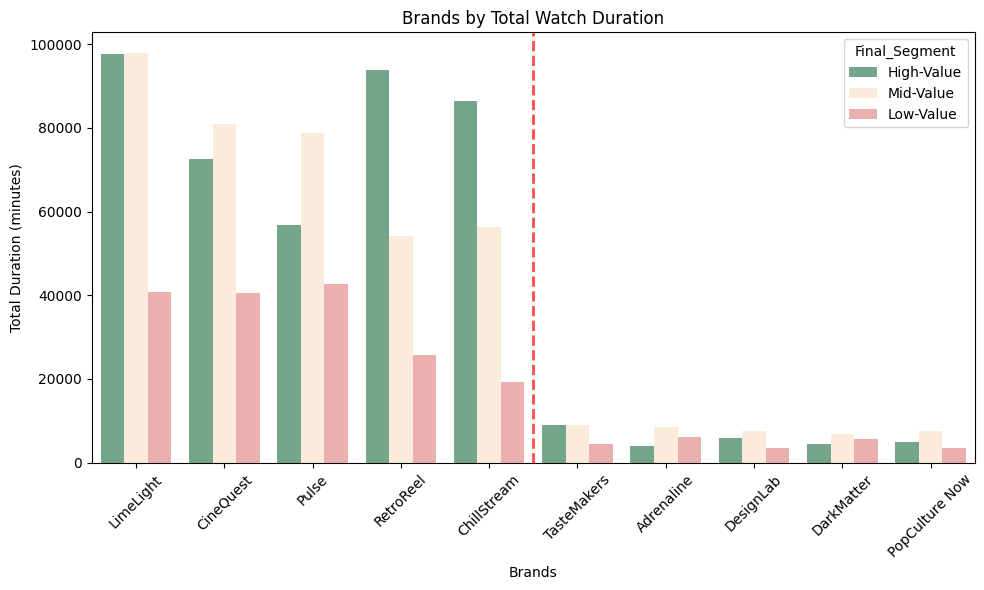

In [142]:
# Group by Final_Segment and NETWORK, and sum the duration
segment_network = view_seg.groupby(['Final_Segment', 'NETWORK'])['DURATION_MINUTES'].sum().reset_index()

network_order = (
    segment_network.groupby('NETWORK')['DURATION_MINUTES']
    .sum()
    .sort_values(ascending=False)
    .index
)

segment_order = ["High-Value","Mid-Value","Low-Value"]

plt.figure(figsize=(10, 6))
sns.barplot(
    x='NETWORK', 
    y='DURATION_MINUTES', 
    hue='Final_Segment', 
    data=segment_network,
    order=network_order,   
    hue_order=segment_order, 
    palette= color_palette,
    alpha = 0.7
)
# Draw vertical line to separate first 5 brands and last 5 brands
plt.axvline(4.5, color='red', linestyle='--', linewidth=2, label="Group Separation", alpha = 0.7)
plt.title('Brands by Total Watch Duration')
plt.xlabel('Brands')
plt.ylabel('Total Duration (minutes)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


Note: Mid value group always have the largest number of users.

In general, linear brands have more watch time than fast brands.

For high/medium value group, they watch linear brands much more than fast brands.

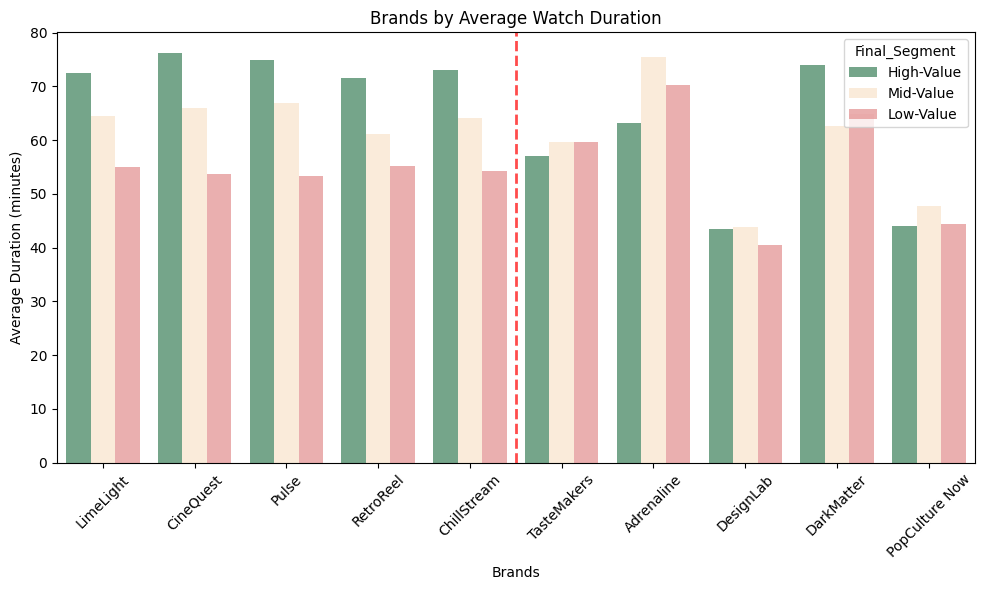

In [143]:
# Group by Final_Segment and NETWORK, and average the duration
segment_network = view_seg.groupby(['Final_Segment', 'NETWORK'])['DURATION_MINUTES'].mean().reset_index()

segment_order = ["High-Value","Mid-Value","Low-Value"]

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(
    x='NETWORK', 
    y='DURATION_MINUTES', 
    hue='Final_Segment', 
    data=segment_network,
    order=network_order,   
    hue_order=segment_order, 
    palette= color_palette,
    alpha = 0.7
)
# Draw vertical line to separate first 5 brands and last 5 brands
plt.axvline(4.5, color='red', linestyle='--', linewidth=2, label="Group Separation", alpha = 0.7)
plt.title('Brands by Average Watch Duration')
plt.xlabel('Brands')
plt.ylabel('Average Duration (minutes)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

For linear channels, high value users have the highest average watch time.

However, for fast channels, the three groups' average watch time are very close.

### Genre Analysis

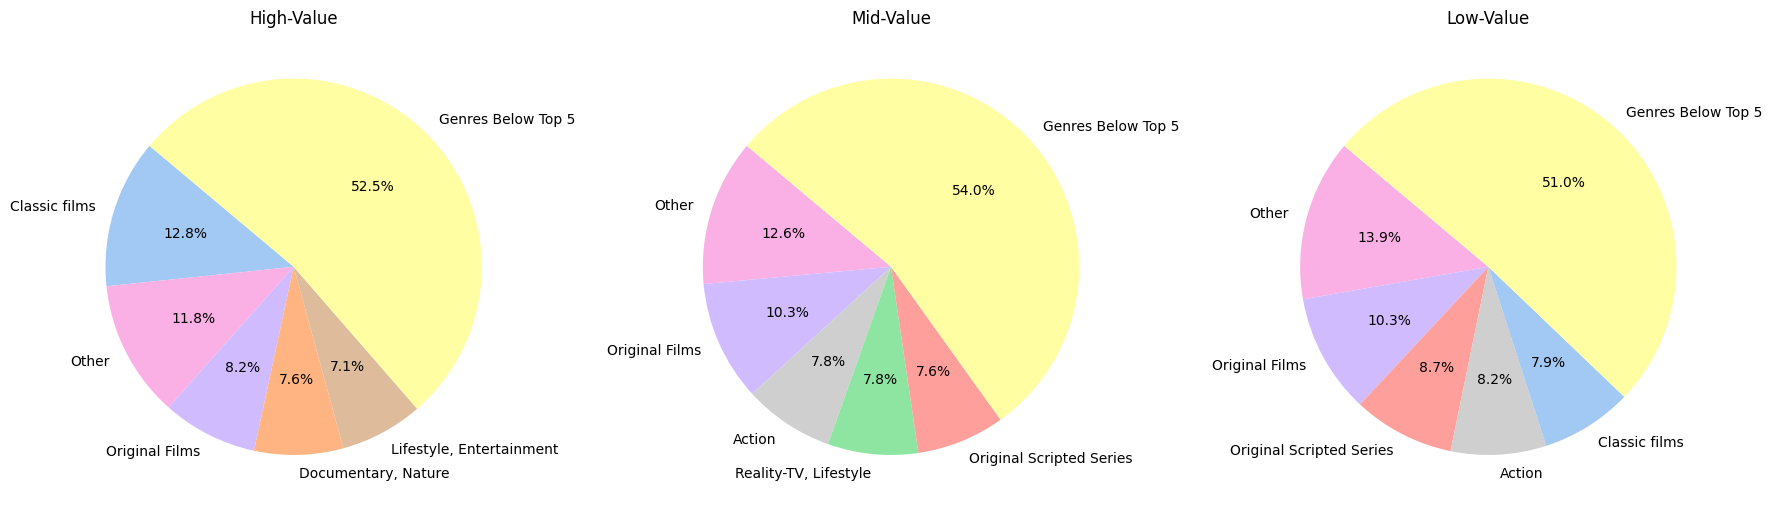

In [144]:
def prepare_pie_data(df, final_value):
    # Filter the dataset for the given Final_Segment value
    subset = df[df['Final_Segment'] == final_value]

    # Group by GENRE and sum the total DURATION_MINUTES
    genre_duration = subset.groupby('GENRE')['DURATION_MINUTES'].sum().reset_index()

    # Sort genres by total duration in descending order
    genre_duration = genre_duration.sort_values('DURATION_MINUTES', ascending=False)

    # Select top 5 genres
    top_5 = genre_duration.head(5)

    # Determine the label for the remainder
    other_label = "Other"
    if 'Other' in top_5['GENRE'].values:
        other_label = "Genres Below Top 5"

    # Sum the remaining genres into 'Other' or 'All Others'
    remaining_sum = genre_duration.iloc[5:]['DURATION_MINUTES'].sum()

    # Append the combined remainder to top 5
    pie_data = top_5.append({'GENRE': other_label, 'DURATION_MINUTES': remaining_sum}, ignore_index=True)
    return pie_data

# Prepare data for each Final_Segment category
low_data = prepare_pie_data(view_seg, 'Low-Value')
mid_data = prepare_pie_data(view_seg, 'Mid-Value')
high_data = prepare_pie_data(view_seg, 'High-Value')

# Get a set of all genres across all three data sets
all_genres = set(low_data['GENRE']).union(mid_data['GENRE'], high_data['GENRE'])

palette = sns.color_palette('pastel', n_colors=len(all_genres))
genre_colors = dict(zip(all_genres, palette))

# Create color lists for each pie based on the order of genres in each dataset
low_colors = [genre_colors[g] for g in low_data['GENRE']]
mid_colors = [genre_colors[g] for g in mid_data['GENRE']]
high_colors = [genre_colors[g] for g in high_data['GENRE']]

# Create a figure with 3 subplots side-by-side
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Plot High-Value pie chart
axes[0].pie(
    high_data['DURATION_MINUTES'],
    labels=high_data['GENRE'],
    autopct='%1.1f%%',
    startangle=140,
    colors=high_colors
)
axes[0].set_title('High-Value')

# Plot Mid-Value pie chart
axes[1].pie(
    mid_data['DURATION_MINUTES'],
    labels=mid_data['GENRE'],
    autopct='%1.1f%%',
    startangle=140,
    colors=mid_colors,
)
axes[1].set_title('Mid-Value')

# Plot Low-Value pie chart
axes[2].pie(
    low_data['DURATION_MINUTES'],
    labels=low_data['GENRE'],
    autopct='%1.1f%%',
    startangle=140,
    colors=low_colors
)
axes[2].set_title('Low-Value')

plt.tight_layout()
plt.show()


For High value users, they watch more classic films and documentary than mid/low groups. We can say high value groups like more premium content.

For Low value group, they are into original films and action, which we can say is more popular content.

### Viewing Time Analysis

In [145]:
# Define a function to categorize the time into a period
def label_time_period(dt):
    hour = dt.hour
    if 0 <= hour < 6:
        return 'Late Night'
    elif 6 <= hour < 12:
        return 'Morning'
    elif 12 <= hour < 18:
        return 'Afternoon'
    else:
        return 'Evening'

view_seg['Time_Period'] = view_seg['EVENT_START_TIMESTAMP'].apply(label_time_period)


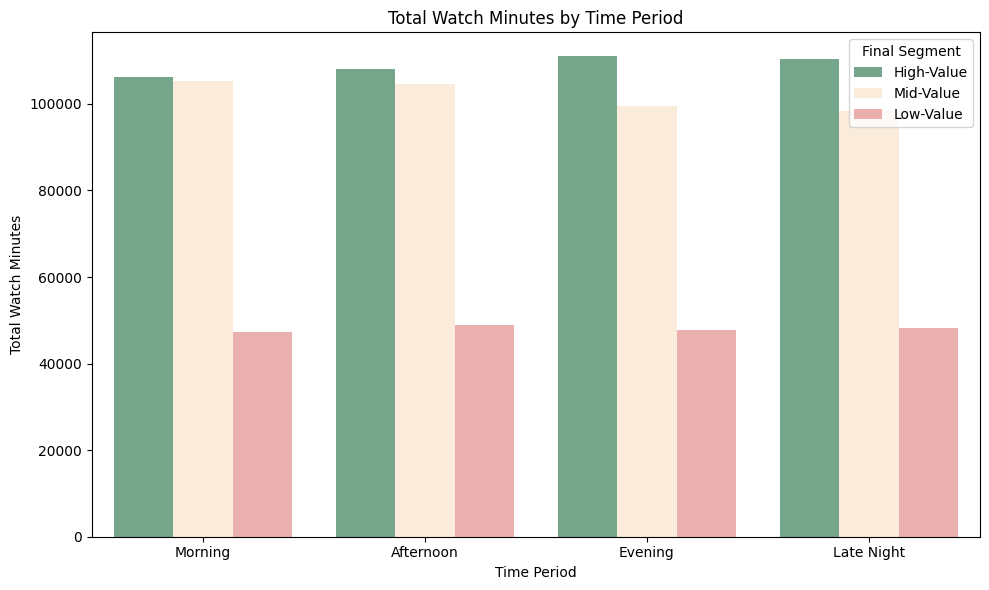

In [146]:
# Group by both Final_Segment and Time_Period to sum the total watch minutes
grouped_data = view_seg.groupby(['Final_Segment', 'Time_Period'])['DURATION_MINUTES'].sum().reset_index()

final_segment_order = ['High-Value', 'Mid-Value', 'Low-Value'] 
time_period_order = ['Morning', 'Afternoon', 'Evening', 'Late Night']  

grouped_data['Final_Segment'] = pd.Categorical(grouped_data['Final_Segment'], categories=final_segment_order, ordered=True)
grouped_data['Time_Period'] = pd.Categorical(grouped_data['Time_Period'], categories=time_period_order, ordered=True)

# Create a bar plot with Time_Period on the x-axis and DURATION_MINUTES on y, hue by Final_Segment
plt.figure(figsize=(10, 6))
sns.barplot(
    x='Time_Period',
    y='DURATION_MINUTES',
    hue='Final_Segment',
    data=grouped_data,
    ci=None,
    palette=color_palette,
    alpha = 0.7
)

plt.title('Total Watch Minutes by Time Period')
plt.xlabel('Time Period')
plt.ylabel('Total Watch Minutes')
plt.legend(title='Final Segment')
plt.tight_layout()
plt.show()


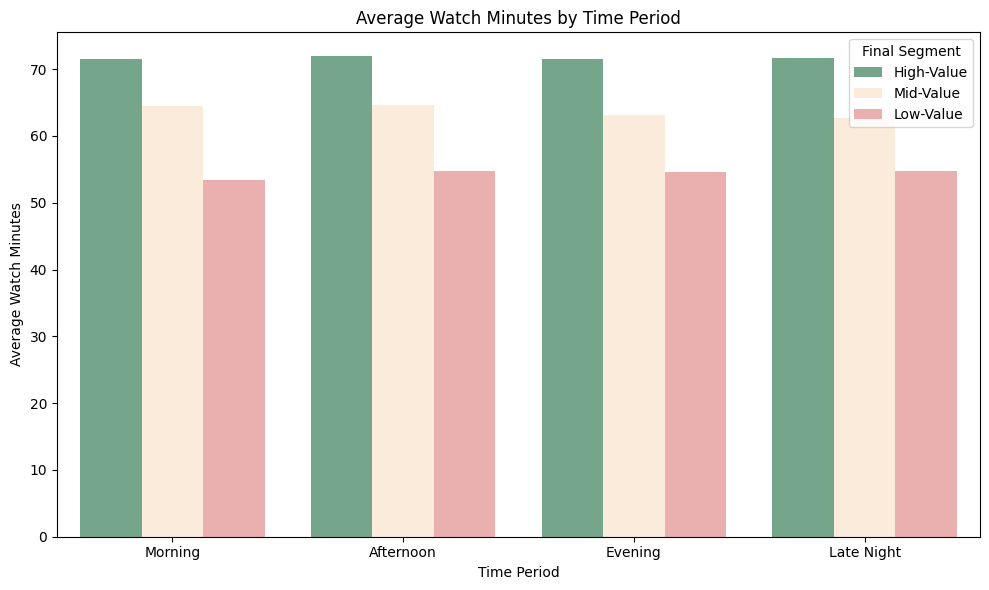

In [147]:
# Group by both Final_Segment and Time_Period to average the total watch minutes
grouped_data = view_seg.groupby(['Final_Segment', 'Time_Period'])['DURATION_MINUTES'].mean().reset_index()

final_segment_order = ['High-Value', 'Mid-Value', 'Low-Value'] 
time_period_order = ['Morning', 'Afternoon', 'Evening', 'Late Night']  

grouped_data['Final_Segment'] = pd.Categorical(grouped_data['Final_Segment'], categories=final_segment_order, ordered=True)
grouped_data['Time_Period'] = pd.Categorical(grouped_data['Time_Period'], categories=time_period_order, ordered=True)

# Create a bar plot with Time_Period on the x-axis and DURATION_MINUTES on y, hue by Final_Segment
plt.figure(figsize=(10, 6))
sns.barplot(
    x='Time_Period',
    y='DURATION_MINUTES',
    hue='Final_Segment',
    data=grouped_data,
    ci=None,
    palette=color_palette,
    alpha = 0.7
)

plt.title('Average Watch Minutes by Time Period')
plt.xlabel('Time Period')
plt.ylabel('Average Watch Minutes')
plt.legend(title='Final Segment')
plt.tight_layout()
plt.show()


There is no clear trend of different time view in a day.

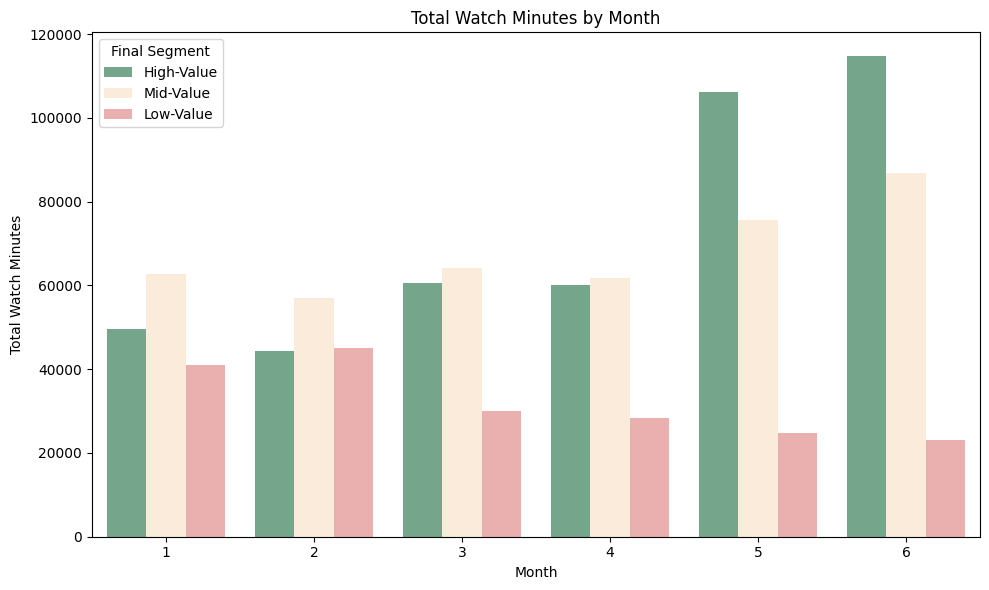

In [148]:
# Extract month from EVENT_START_TIMESTAMP
view_seg['Month'] = view_seg['EVENT_START_TIMESTAMP'].dt.month

# Group by Final_Segment and Month, then sum DURATION_MINUTES
grouped_by_month = view_seg.groupby(['Final_Segment', 'Month'])['DURATION_MINUTES'].sum().reset_index()

# Define the order for the Final_Segment if needed
final_segments_order = ["High-Value", "Mid-Value", "Low-Value"]
grouped_by_month['Final_Segment'] = pd.Categorical(
    grouped_by_month['Final_Segment'],
    categories=final_segments_order,
    ordered=True
)

# Plot the sum of duration by month for each group
plt.figure(figsize=(10, 6))
sns.barplot(
    x='Month', 
    y='DURATION_MINUTES', 
    hue='Final_Segment', 
    data=grouped_by_month,
    ci=None,
    palette=color_palette,
    alpha = 0.7
)

plt.title('Total Watch Minutes by Month')
plt.xlabel('Month')
plt.ylabel('Total Watch Minutes')
plt.legend(title='Final Segment')
plt.tight_layout()
plt.show()


High and Medium value users have the highest viewing duration in **May** and **June** while Low value users have the highest viewing duration in **Janauary** and **Feburary**.

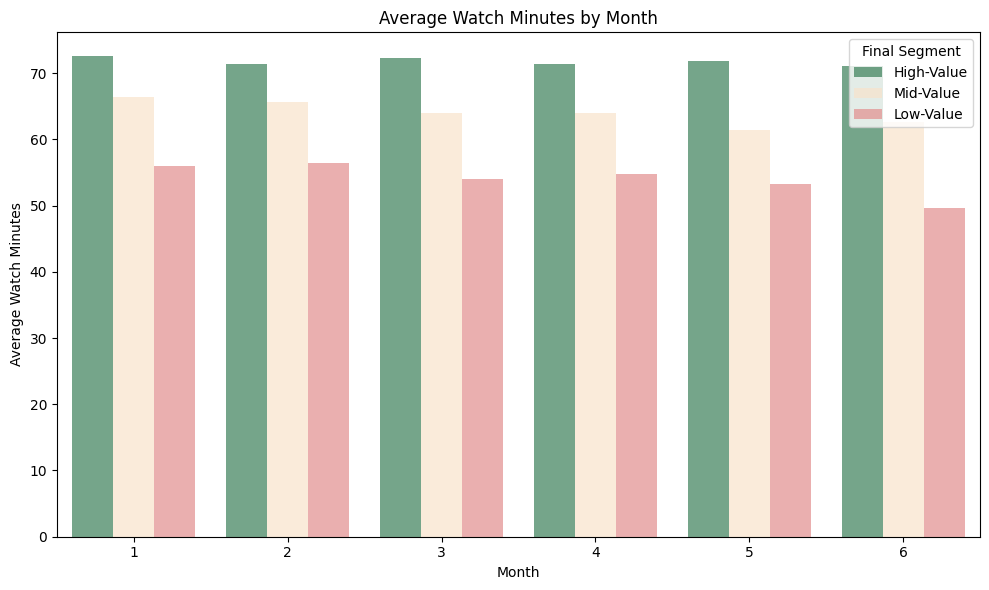

In [149]:
# Group by Final_Segment and Month, then average DURATION_MINUTES
grouped_by_month = view_seg.groupby(['Final_Segment', 'Month'])['DURATION_MINUTES'].mean().reset_index()

# Define the order for the Final_Segment if needed
final_segments_order = ["High-Value", "Mid-Value", "Low-Value"]
grouped_by_month['Final_Segment'] = pd.Categorical(
    grouped_by_month['Final_Segment'],
    categories=final_segments_order,
    ordered=True
)

# Plot the sum of duration by month for each group
plt.figure(figsize=(10, 6))
sns.barplot(
    x='Month', 
    y='DURATION_MINUTES', 
    hue='Final_Segment', 
    data=grouped_by_month,
    ci=None,
    palette=color_palette,
    alpha = 0.7
)

plt.title('Average Watch Minutes by Month')
plt.xlabel('Month')
plt.ylabel('Average Watch Minutes')
plt.legend(title='Final Segment')
plt.tight_layout()
plt.show()


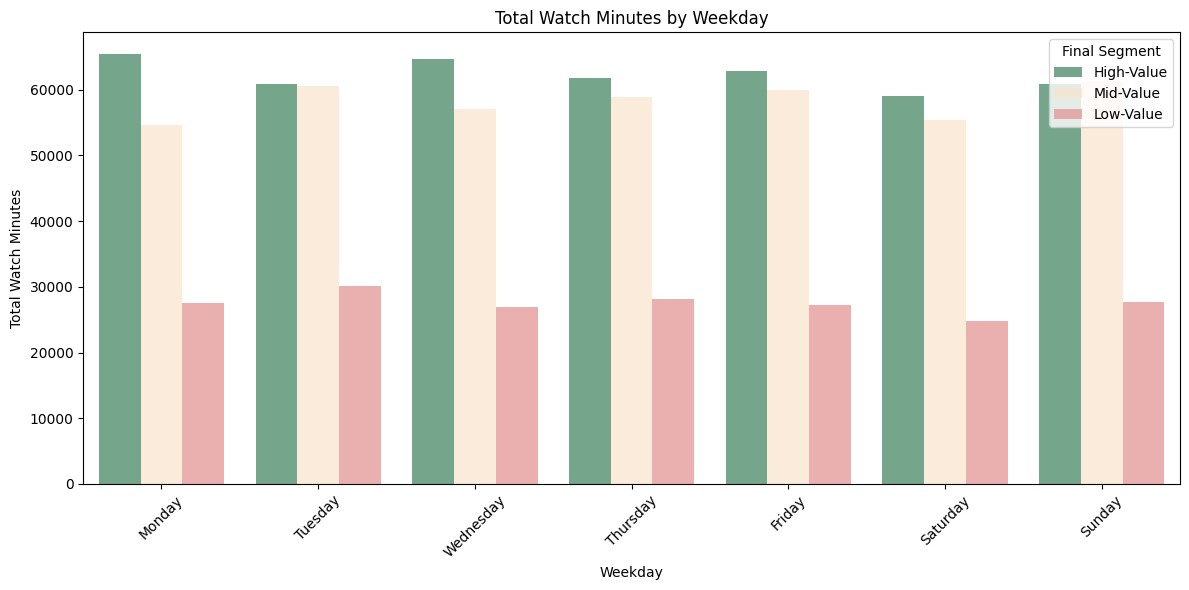

In [150]:
# Extract weekday name (e.g., Monday, Tuesday...)
view_seg['Weekday'] = view_seg['EVENT_START_TIMESTAMP'].dt.day_name()

# Define the order of weekdays from Monday to Sunday
weekday_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
view_seg['Weekday'] = pd.Categorical(view_seg['Weekday'], categories=weekday_order, ordered=True)

# Group by Final_Segment and Weekday, sum DURATION_MINUTES
grouped_by_weekday = view_seg.groupby(['Final_Segment', 'Weekday'])['DURATION_MINUTES'].sum().reset_index()

# Define the order for the Final_Segment if needed
final_segments_order = ["High-Value", "Mid-Value", "Low-Value"]
grouped_by_weekday['Final_Segment'] = pd.Categorical(
    grouped_by_weekday['Final_Segment'],
    categories=final_segments_order,
    ordered=True
)

# Plot the sum of duration by weekday for each group
plt.figure(figsize=(12, 6))
sns.barplot(
    x='Weekday', 
    y='DURATION_MINUTES', 
    hue='Final_Segment', 
    data=grouped_by_weekday,
    ci=None,
    palette=color_palette,
    alpha = 0.7
)

plt.title('Total Watch Minutes by Weekday')
plt.xlabel('Weekday')
plt.ylabel('Total Watch Minutes')
plt.legend(title='Final Segment')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

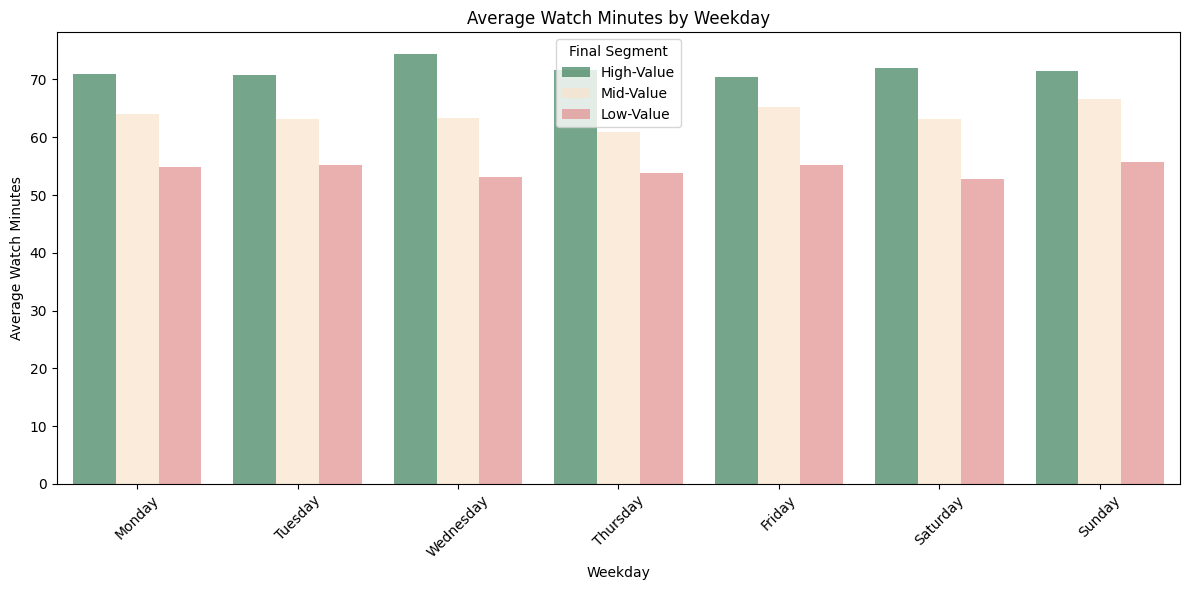

In [151]:
# Group by Final_Segment and Weekday, average DURATION_MINUTES
grouped_by_weekday = view_seg.groupby(['Final_Segment', 'Weekday'])['DURATION_MINUTES'].mean().reset_index()

grouped_by_weekday['Final_Segment'] = pd.Categorical(
    grouped_by_weekday['Final_Segment'],
    categories=final_segments_order,
    ordered=True
)

# Plot the sum of duration by weekday for each group
plt.figure(figsize=(12, 6))
sns.barplot(
    x='Weekday', 
    y='DURATION_MINUTES', 
    hue='Final_Segment', 
    data=grouped_by_weekday,
    ci=None,
    palette=color_palette,
    alpha = 0.7
)

plt.title('Average Watch Minutes by Weekday')
plt.xlabel('Weekday')
plt.ylabel('Average Watch Minutes')
plt.legend(title='Final Segment')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


There is no clear pattern for weekdays. Every day seems to have the same pattern.

### Most watched Program

In [152]:
# Group by Final_Segment, PROGRAM_NAME, GENRE, and NETWORK to sum total watch minutes
grouped_shows = (
    view_seg
    .groupby(['Final_Segment', 'PROGRAM_NAME', 'GENRE', 'NETWORK'])['DURATION_MINUTES']
    .sum()
    .reset_index()
)

# Sort by Final_Segment and DURATION_MINUTES (descending)
grouped_shows = grouped_shows.sort_values(['Final_Segment', 'DURATION_MINUTES'], ascending=[True, False])

# For each Final_Segment, get top 5 shows
top_5_shows_per_group = grouped_shows.groupby('Final_Segment').head(5).reset_index(drop=True)

# Define the desired order for Final_Segment
final_segments_order = ["High-Value", "Mid-Value", "Low-Value"]

# Create a final table
final_table = pd.DataFrame()

for seg in final_segments_order:
    seg_df = top_5_shows_per_group[top_5_shows_per_group['Final_Segment'] == seg].copy()
    seg_df.reset_index(drop=True, inplace=True)
    final_table = pd.concat([final_table, seg_df], ignore_index=True)

from IPython.display import display

display(final_table)

final_table.to_excel('final_table.xlsx', index=False)

,Final_Segment,PROGRAM_NAME,GENRE,NETWORK,DURATION_MINUTES
0,High-Value,Extreme Makeovers: House Flips,"Lifestyle, Entertainment",LimeLight,11892.8
1,High-Value,The Perfect Party Planner,Lifestyle,LimeLight,11012.4
2,High-Value,Retro Sci-Fi: Space and Beyond,Classic films,RetroReel,10219.1
3,High-Value,Fitness Gurus: Transformations,Entertainment,LimeLight,10133.7
4,High-Value,Timeless Thrillers: Hitchcock’s Legacy,Other,RetroReel,10091.0
5,Mid-Value,Behind the Glam: Celebrity Secrets,"Reality-TV, Lifestyle",LimeLight,12500.2
6,Mid-Value,Style Seekers: Global Trends,Reality-TV,LimeLight,10965.4
7,Mid-Value,Destination Wedding Dreams,Reality-TV,LimeLight,10384.3
8,Mid-Value,Home Makeover Rescue,"Reality-TV, Lifestyle",LimeLight,9651.8
9,Mid-Value,Unwritten Laws,Original Films,CineQuest,9549.9


In [153]:
# Group by Final_Segment, PROGRAM_NAME, GENRE, and NETWORK to sum total watch minutes
grouped_shows = (
    view_seg
    .groupby(['Final_Segment', 'PROGRAM_NAME', 'GENRE', 'NETWORK'])['DURATION_MINUTES']
    .sum()
    .reset_index()
)

# Sort by Final_Segment and DURATION_MINUTES (descending)
grouped_shows = grouped_shows.sort_values(['Final_Segment', 'DURATION_MINUTES'], ascending=[True, False])

# For each Final_Segment, get top 5 shows
top_5_shows_per_group = grouped_shows.groupby('Final_Segment').head(5).reset_index(drop=True)

# Define the desired order for Final_Segment
final_segments_order = ["High-Value", "Mid-Value", "Low-Value"]

for seg in final_segments_order:
    seg_df = top_5_shows_per_group[top_5_shows_per_group['Final_Segment'] == seg].copy()
    seg_df.reset_index(drop=True, inplace=True)
    
    print(f"Top 5 Shows for {seg}:")
    display(seg_df)
    print("\n")

Top 5 Shows for High-Value:


,Final_Segment,PROGRAM_NAME,GENRE,NETWORK,DURATION_MINUTES
0,High-Value,Extreme Makeovers: House Flips,"Lifestyle, Entertainment",LimeLight,11892.8
1,High-Value,The Perfect Party Planner,Lifestyle,LimeLight,11012.4
2,High-Value,Retro Sci-Fi: Space and Beyond,Classic films,RetroReel,10219.1
3,High-Value,Fitness Gurus: Transformations,Entertainment,LimeLight,10133.7
4,High-Value,Timeless Thrillers: Hitchcock’s Legacy,Other,RetroReel,10091.0




Top 5 Shows for Mid-Value:


,Final_Segment,PROGRAM_NAME,GENRE,NETWORK,DURATION_MINUTES
0,Mid-Value,Behind the Glam: Celebrity Secrets,"Reality-TV, Lifestyle",LimeLight,12500.2
1,Mid-Value,Style Seekers: Global Trends,Reality-TV,LimeLight,10965.4
2,Mid-Value,Destination Wedding Dreams,Reality-TV,LimeLight,10384.3
3,Mid-Value,Home Makeover Rescue,"Reality-TV, Lifestyle",LimeLight,9651.8
4,Mid-Value,Unwritten Laws,Original Films,CineQuest,9549.9




Top 5 Shows for Low-Value:


,Final_Segment,PROGRAM_NAME,GENRE,NETWORK,DURATION_MINUTES
0,Low-Value,Midnight Pursuit,"Action, Adventure",Pulse,5482.3
1,Low-Value,Destination Wedding Dreams,Reality-TV,LimeLight,5454.0
2,Low-Value,Highway Heist,Action,Pulse,5390.1
3,Low-Value,Edge of Extinction,"Action, Adventure, Thriller",Pulse,4979.5
4,Low-Value,Fallen Crown: The Battle for the Throne,Original Scripted Series,CineQuest,4605.7


In [154]:
# Group by Final_Segment, Time_Period, and NETWORK to find total DURATION_MINUTES
grouped = view_seg.groupby(['Final_Segment', 'Time_Period', 'NETWORK'])['DURATION_MINUTES'].sum().reset_index()

# For each combination of Final_Segment and Time_Period, find the NETWORK with the maximum DURATION_MINUTES
top_brands = (
    grouped
    .sort_values('DURATION_MINUTES', ascending=False)
    .groupby(['Final_Segment', 'Time_Period'], as_index=False)
    .first()  # Picks the row with the highest DURATION_MINUTES after sorting
)

# Define the desired order for Final_Segment
final_segments_order = ["High-Value", "Mid-Value", "Low-Value"]

# Display each Final_Segment group in its own table
for seg in final_segments_order:
    seg_df = top_brands[top_brands['Final_Segment'] == seg].copy()
    seg_df.reset_index(drop=True, inplace=True)
    
    print(f"Top Brands for {seg}:")
    display(seg_df)
    print("\n")


Top Brands for High-Value:


,Final_Segment,Time_Period,NETWORK,DURATION_MINUTES
0,High-Value,Afternoon,LimeLight,24520.3
1,High-Value,Evening,LimeLight,24518.9
2,High-Value,Late Night,RetroReel,26126.6
3,High-Value,Morning,LimeLight,25025.5




Top Brands for Mid-Value:


,Final_Segment,Time_Period,NETWORK,DURATION_MINUTES
0,Mid-Value,Afternoon,LimeLight,26150.9
1,Mid-Value,Evening,LimeLight,22184.2
2,Mid-Value,Late Night,LimeLight,23508.0
3,Mid-Value,Morning,LimeLight,26099.0




Top Brands for Low-Value:


,Final_Segment,Time_Period,NETWORK,DURATION_MINUTES
0,Low-Value,Afternoon,Pulse,11911.1
1,Low-Value,Evening,CineQuest,10671.2
2,Low-Value,Late Night,CineQuest,10315.1
3,Low-Value,Morning,Pulse,11323.7
